# 6. Exploratory Analysis for American Airlines Discrepancies
## Set Up Environment
**Go [here](01_import_data.ipynb) if you are following along and have not configured the virtual environment and installed dependencies.**

In [2]:
# Jupyter magic
%run ../util/dependencies.py
%load_ext sql

## Import new data (2022-2023) for AA
I'm importing the new SDRs from the FAA concerning only AA writeups for safety discrepancies that they observed from jan 2022-dec 2023. **There is a noticable drop in issues notated from q1-q3 of 2022, and this can be attributed to a change in the Service Discrepancy Reporting System (SDRS) that the FAA implemented in 2021-2022. Many other users have noted this issue as well.**

In [2]:
filepath = '../data/01_raw/sdrs'
filenames = os.listdir(filepath)
filenames = [filepath + '/' + f for f in filenames]

# try opening first file
if(not pd.read_html(filenames[0])):
   print('ERROR LOADING FILES')

df = pd.read_html(filenames[0])[0]

# concat other files
if len(filenames) > 1:
    for f in filenames[1:]:
        df = pd.concat([df, pd.read_html(f)[0]], ignore_index=True)

# export
df.to_csv("../data/02_csv/SDR_COMPOSITE_EXPORT.csv", index=False)

In [ ]:
DROP TABLE sdr_raw;

CREATE TABLE IF NOT EXISTS sdr_raw (
  OperatorControlNumber        text,
  DifficultyDate               text,
  SubmissionDate               text,
  OperatorDesignator           text,
  SubmitterDesignator          text,
  SubmitterTypeCode            text,
  ReceivingRegionCode          text,
  ReceivingDistrictOffice      text,
  SDRType                      text,
  JASCCode                     text,
  NatureOfConditionA           text,
  NatureOfConditionB           text,
  NatureOfConditionC           text,
  PrecautionaryProcedureA      text,
  PrecautionaryProcedureB      text,
  PrecautionaryProcedureC      text,
  PrecautionaryProcedureD      text,
  StageOfOperationCode         text,
  HowDiscoveredCode            text,
  RegistryNNumber              text,
  AircraftMake                 text,
  AircraftModel                text,
  AircraftSerialNumber         text,
  AircraftTotalTime            text,
  AircraftTotalCycles          text,
  EngineMake                   text,
  EngineModel                  text,
  EngineSerialNumber           text,
  EngineTotalTime              text,
  EngineTotalCycles            text,
  PropellerMake                text,
  PropellerModel               text,
  PropellerSerialNumber        text,
  PropellerTotalTime           text,
  PropellerTotalCycles         text,
  PartMake                     text,
  PartName                     text,
  PartNumber                   text,
  PartSerialNumber             text,
  PartCondition                text,
  PartLocation                 text,
  PartTotalTime                text,
  PartTotalCycles              text,
  PartTimeSince                text,
  PartSinceCode                text,
  ComponentMake                text,
  ComponentModel               text,
  ComponentName                text,
  ComponentPartNumber          text,
  ComponentSerialNumber        text,
  ComponentLocation            text,
  ComponentTotalTime           text,
  ComponentTotalCycles         text,
  ComponentTimeSince           text,
  ComponentSinceCode           text,
  FuselageStationFrom          text,
  FuselageStationTo            text,
  StringerFrom                 text,
  StringerFromSide             text,
  StringerTo                   text,
  StringerToSide               text,
  WingStationFrom              text,
  WingStationFromSide          text,
  WingStationTo                text,
  WingStationToSide            text,
  ButtLineFrom                 text,
  ButtLineFromSide             text,
  ButtLineTo                   text,
  ButtLineToSide               text,
  WaterLineFrom                text,
  WaterLineTo                  text,
  CrackLength                  text,
  NumberOfCracks               text,
  CorrosionLevel               text,
  StructuralOther              text,
  Discrepancy                  text
);

In [3]:
# 'vectra' database connection
db_connection = psycopg2.connect(dbname='vectra',
                                 host='localhost',
                                 user='robb',
                                 password='thek3yisK#')
cur = db_connection.cursor()

# copy contents to sdr_raw table
with open('../data/02_csv/SDR_COMPOSITE_EXPORT.csv', 'r') as f:
    cur.copy_expert("""
        COPY sdr_raw
        FROM STDIN
        WITH CSV HEADER
    """, f)

# commit and close the connection
db_connection.commit()
cur.close()
db_connection.close()

In [ ]:
-- ==========================================================================
-- Populating the Master Tables (aircraft, ata_chapter, jasc_code & operator)
-- ==========================================================================

-- aircraft
INSERT INTO aircraft (
    registry_n_number,
    make,
    model,
    serial_number,
    total_time,
    total_cycles
)
SELECT
    RegistryNNumber,
    MAX(AircraftMake) AS make,
    MAX(AircraftModel) AS model,
    MAX(AircraftSerialNumber) AS serial_number,
    MAX(AircraftTotalTime::float) AS total_time,
    MAX(AircraftTotalCycles::float) AS total_cycles
FROM sdr_raw
WHERE RegistryNNumber IS NOT NULL
GROUP BY RegistryNNumber
ON CONFLICT (registry_n_number) DO UPDATE
SET
    make = EXCLUDED.make,
    model = EXCLUDED.model,
    serial_number = EXCLUDED.serial_number,
    total_time = GREATEST(aircraft.total_time, EXCLUDED.total_time),
    total_cycles = GREATEST(aircraft.total_cycles, EXCLUDED.total_cycles);

In [ ]:
-- ==============================
-- Populating the sdr_event Table
-- ==============================
INSERT INTO sdr_event (
    operator_control_number,
    difficulty_date,
    submission_date,
    operator_designator_id,
    submitter_designator_id,
    submitter_type_code,
    receiving_region_code,
    receiving_district_office,
    sdr_type,
    nature_condition_a,
    nature_condition_b,
    nature_condition_c,
    precautionary_proc_a,
    precautionary_proc_b,
    precautionary_proc_c,
    precautionary_proc_d,
    stage_of_operation,
    how_discovered,
    discrepancy,

    -- Foreign keys
    aircraft_id,
    operator_id,
    jasc_code,

    -- ENGINE (event-specific)
    engine_make,
    engine_model,
    engine_serial_number,
    engine_total_time,
    engine_total_cycles,

    -- PROPELLER (event-specific)
    propeller_make,
    propeller_model,
    propeller_serial_number,
    propeller_total_time,
    propeller_total_cycles,

    -- PART (event-specific)
    part_make,
    part_name,
    part_number,
    part_serial_number,
    part_condition,
    part_location,
    part_total_time,
    part_total_cycles,
    part_time_since,
    part_since_code,

    -- COMPONENT (event-specific)
    component_make,
    component_model,
    component_name,
    component_part_number,
    component_serial_number,
    component_location,
    component_total_time,
    component_total_cycles,
    component_time_since,
    component_since_code,

    -- STRUCTURAL LOCATION (event-specific)
    fuselage_station_from,
    fuselage_station_to,
    stringer_from,
    stringer_from_side,
    stringer_to,
    stringer_to_side,
    wing_station_from,
    wing_station_from_side,
    wing_station_to,
    wing_station_to_side,
    butt_line_from,
    butt_line_from_side,
    butt_line_to,
    butt_line_to_side,
    water_line_from,
    water_line_to,
    crack_length,
    number_of_cracks,
    corrosion_level,
    structural_other
    )
SELECT 
    r.OperatorControlNumber,
    r.DifficultyDate::date,
    r.SubmissionDate::date,

    o_op.id, --this is supposed to not be the operator designator, but the id for that operator
    o_sub.id, --this too for submitter, its the id

    r.SubmitterTypeCode,
    r.ReceivingRegionCode,
    r.ReceivingDistrictOffice,
    r.SDRType,
    r.NatureOfConditionA,
    r.NatureOfConditionB,
    r.NatureOfConditionC,
    r.PrecautionaryProcedureA,
    r.PrecautionaryProcedureB,
    r.PrecautionaryProcedureC,
    r.PrecautionaryProcedureD,
    r.StageOfOperationCode,
    r.HowDiscoveredCode,
    r.Discrepancy,

    a.id AS aircraft_id,
    o_op.id AS operator_id,
    j.jasc_code, -- reference automatic?

    r.EngineMake,
    r.EngineModel,
    r.EngineSerialNumber,
    r.EngineTotalTime::float,
    r.EngineTotalCycles::float,

    r.PropellerMake,
    r.PropellerModel,
    r.PropellerSerialNumber,
    r.PropellerTotalTime::float,
    r.PropellerTotalCycles::float,

    r.PartMake,
    r.PartName,
    r.PartNumber,
    r.PartSerialNumber,
    r.PartCondition,
    r.PartLocation,
    r.PartTotalTime::float,
    r.PartTotalCycles::float,
    r.PartTimeSince::float,
    r.PartSinceCode,

    r.ComponentMake,
    r.ComponentModel,
    r.ComponentName,
    r.ComponentPartNumber,
    r.ComponentSerialNumber,
    r.ComponentLocation,
    r.ComponentTotalTime::float,
    r.ComponentTotalCycles::float,
    r.ComponentTimeSince::float,
    r.ComponentSinceCode,

    r.FuselageStationFrom,
    r.FuselageStationTo,
    r.StringerFrom,
    r.StringerFromSide,
    r.StringerTo,
    r.StringerToSide,
    r.WingStationFrom,
    r.WingStationFromSide,
    r.WingStationTo,
    r.WingStationToSide,
    r.ButtLineFrom,
    r.ButtLineFromSide,
    r.ButtLineTo,
    r.ButtLineToSide,
    r.WaterLineFrom,
    r.WaterLineTo,
    r.CrackLength,
    r.NumberOfCracks::float,
    r.CorrosionLevel,
    r.StructuralOther
FROM sdr_raw AS r
    LEFT JOIN aircraft AS a
        ON a.registry_n_number = r.RegistryNNumber
    LEFT JOIN operator AS o_op
        ON o_op.sdr_prefix = r.OperatorDesignator
    LEFT JOIN operator AS o_sub
        ON o_sub.sdr_prefix = r.SubmitterDesignator
    LEFT JOIN jasc_code AS j
        ON j.jasc_code = r.JASCCode
WHERE OperatorControlNumber IS NOT NULL
ON CONFLICT (operator_control_number) DO NOTHING;



CREATE EXTENSION IF NOT EXISTS pg_trgm;

-- update schema
ALTER TABLE sdr_event
ADD COLUMN IF NOT EXISTS aog_flag boolean;

-- add aog_flag
-- want to avoid 'NOT GROUNDED'
UPDATE sdr_event
SET aog_flag = 
    CASE
        -- ==========
        -- FALSE WHEN
        -- ==========
        WHEN (stage_of_operation = 'IN') THEN False --dont inlcude inspections, not in flight
        WHEN (UPPER(discrepancy) LIKE '%NOT GROUNDED%') THEN False
        WHEN (UPPER(discrepancy) LIKE '%NOT AOG%') THEN False
        WHEN (UPPER(discrepancy) LIKE '%NOT REMOVED FROM SERVICE%') THEN False

        -- ==========
        -- TRUE WHEN
        -- ==========
        WHEN (UPPER(discrepancy) LIKE '%WAS GROUNDED%') OR
            (similarity(UPPER(discrepancy), 'WAS GROUNDED') > 0.25) OR -- close?
            ((similarity(UPPER(discrepancy), 'GROUNDED') > 0.25) AND UPPER(discrepancy) NOT LIKE '%NOT GROUNDED%') OR
            (UPPER(discrepancy) LIKE '%AOG%' AND UPPER(discrepancy) NOT LIKE '%NOT AOG%') OR
            (UPPER(discrepancy) LIKE '%UNABLE TO DISPATCH%') OR
            (UPPER(discrepancy) LIKE '%AIRCRAFT DOWN%') OR
            (UPPER(discrepancy) LIKE '%REMOVED FROM SERVICE%' AND UPPER(discrepancy) NOT LIKE '%NOT REMOVED FROM SERVICE%')
            THEN True
        -- ==========
        -- DEFAULT
        -- ==========
        ELSE False
    END;



--UPDATe schema
ALTER TABLE sdr_event
ADD COLUMN IF NOT EXISTS severity int;

--update values
UPDATE sdr_event
SET severity =
    CASE
        -- =================
        -- (3) HIGH SEVERITY
        -- =================
        WHEN
            (aog_flag = True) OR
            UPPER(discrepancy) LIKE '%EMERGENCY WAS DECLARED%' OR
            similarity(lower(discrepancy), 'unable to dispatch') > 0.25 OR
            similarity(lower(discrepancy), 'aircraft down') > 0.25 OR
            similarity(lower(discrepancy), 'removed from service') > 0.25 OR
            similarity(lower(discrepancy), 'emergency was declared') > 0.25 OR
            similarity(lower(discrepancy), 'returned to gate') > 0.25 OR
            similarity(lower(discrepancy), 'diverted') > 0.25 OR
            similarity(lower(discrepancy), 'aborted takeoff') > 0.25 OR
            similarity(lower(discrepancy), 'aborted landing') > 0.25 OR
            similarity(lower(discrepancy), 'shutdown in flight') > 0.25 OR
            similarity(lower(discrepancy), 'in-flight failure') > 0.25 OR
            similarity(lower(discrepancy), 'loss of pressure') > 0.25 OR
            similarity(lower(discrepancy), 'loss of control') > 0.25 OR
            similarity(lower(discrepancy), 'smoke') > 0.25 OR
            similarity(lower(discrepancy), 'fire') > 0.25 OR
            similarity(lower(discrepancy), 'burning smell') > 0.25 OR
            similarity(lower(discrepancy), 'overhead') > 0.25 OR
            similarity(lower(discrepancy), 'fuel leak') > 0.25 OR
            similarity(lower(discrepancy), 'aborted') > 0.25 OR
            similarity(lower(discrepancy), 'hydraulic leak') > 0.25
        THEN 3

        -- ================
        -- (2) MED SEVERITY
        -- ================
        WHEN
            -- Systems that are important for the safety of the crew, but did not necessitate grounding
            left(jasc_code, 2)::int = 26 OR --fire systems (det, supress)
            left(jasc_code, 2)::int = 27 OR	--Flight controls	Direct safety-of-flight
            left(jasc_code, 2)::int = 32 OR --Landing gear	Takeoff/landing safety
            left(jasc_code, 2)::int= 21 OR --Pressurization	Can cause diversions, emergency descents
            left(jasc_code, 2)::int = 24 OR --Electrical power	Can cascade into multiple system failures
            left(jasc_code, 2)::int = 29 OR--Hydraulicssimilarity(lower(s.discrepancy), 'inoperative') > 0.25 OR
            similarity(lower(discrepancy), 'failed') > 0.25 OR
            similarity(lower(discrepancy), 'fault') > 0.25 OR
            similarity(lower(discrepancy), 'degraded') > 0.25 OR
            similarity(lower(discrepancy), 'intermittent') > 0.25 OR
            similarity(lower(discrepancy), 'pressure issue') > 0.25 OR
            similarity(lower(discrepancy), 'temperature issue') > 0.25 OR
            similarity(lower(discrepancy), 'pack failure') > 0.25 OR
            similarity(lower(discrepancy), 'bleed issue') > 0.25 OR
            similarity(lower(discrepancy), 'autopilot disconnect') > 0.25 OR
            similarity(lower(discrepancy), 'generator offline') > 0.25 OR
            similarity(lower(discrepancy), 'hydraulic quantity low') > 0.25
        THEN 2

        -- ================
        -- (1) LOW SEVERITY
        -- ================
        WHEN
            -- Systems that are important for the safety of the crew, but did not necessitate grounding
            -- or result in a failed system
            left(jasc_code, 2)::int = 22 OR--(Auto flight)
            left(jasc_code, 2)::int = 23 OR--(Communications)
            left(jasc_code, 2)::int = 24 OR--(Electrical) — could be high or medium, good bet
            left(jasc_code, 2)::int= 25 OR--(Equipment/furnishings) — usually medium
            left(jasc_code, 2)::int = 28 OR--(Fuel) — often medium unless leak
            (similarity(UPPER(discrepancy), 'LIFE VEST') > 0.25) OR
            (similarity(UPPER(discrepancy), 'EMER LIGHT') > 0.25) OR
            (similarity(UPPER(discrepancy), 'EMERGENCY LIGHT') > 0.25) OR
            similarity(UPPER(discrepancy), 'seat') > 0.25 OR
            similarity(UPPER(discrepancy), 'tray table') > 0.25 OR
            similarity(UPPER(discrepancy), 'IFE') > 0.25 OR
            similarity(UPPER(discrepancy), 'reading light') > 0.25 OR
            similarity(UPPER(discrepancy), 'emergency light') > 0.25 OR
            similarity(UPPER(discrepancy), 'lavatory') > 0.25 OR
            similarity(UPPER(discrepancy), 'galley') > 0.25 OR
            similarity(UPPER(discrepancy), 'cosmetic') > 0.25 OR
            similarity(UPPER(discrepancy), 'panel loose') > 0.25 OR
            similarity(UPPER(discrepancy), 'placard missing') > 0.25 OR
            left(jasc_code, 2)::int = 25 OR --(Cabin furnishings)
            left(jasc_code, 2)::int = 33 OR --(Lights — except emergency exit lights)
            left(jasc_code, 2)::int= 38 --(Water/waste)
        THEN 1

        -- ========================
        -- (0) NOT SEVERE (default)
        -- ========================
        ELSE 0
    END;



UPDATE sdr_event AS s
SET
    emer_flag =
        CASE
            WHEN lower(s.discrepancy) LIKE '%emergency was declared%'
              OR lower(s.discrepancy) LIKE '%aborted landing%'
              OR similarity(lower(s.discrepancy), 'emergency') > 0.25
              OR similarity(lower(s.discrepancy), 'emer') > 0.25
            THEN TRUE ELSE FALSE
        END,

    divert_flag =
        CASE
            WHEN lower(s.discrepancy) LIKE '%aircraft down%'
              OR lower(s.discrepancy) LIKE '%unable to dispatch%'
              OR lower(s.discrepancy) LIKE '%returned to gate%'
              OR lower(s.discrepancy) LIKE '%diverted%'
              OR lower(s.discrepancy) LIKE '%aborted takeoff%'
            THEN TRUE ELSE FALSE
        END,

    fail_flag =
        CASE
            WHEN lower(s.discrepancy) LIKE '%shutdown in flight%'
              OR lower(s.discrepancy) LIKE '%in-flight failure%'
              OR lower(s.discrepancy) LIKE '%loss of control%'
              OR lower(s.discrepancy) LIKE '%disconnect%'
              OR similarity(lower(s.discrepancy), 'failed') > 0.25
              OR similarity(lower(s.discrepancy), 'failure') > 0.25
            THEN TRUE ELSE FALSE
        END,

    fault_flag =
        CASE
            WHEN lower(s.discrepancy) LIKE '%fault%'
              OR lower(s.discrepancy) LIKE '%degraded%'
              OR lower(s.discrepancy) LIKE '%issue%'
              OR lower(s.discrepancy) LIKE '%low%'
            THEN TRUE ELSE FALSE
        END,

    inter_flag =
        CASE
            WHEN lower(s.discrepancy) LIKE '%intermittent%'
            THEN TRUE ELSE FALSE
        END,

    fire_flag =
        CASE
            WHEN lower(s.discrepancy) LIKE '%smoke%'
              OR lower(s.discrepancy) LIKE '%fire%'
              OR lower(s.discrepancy) LIKE '%burning smell%'
              OR lower(s.discrepancy) LIKE '%fumes%'
              OR lower(s.discrepancy) LIKE '%odor%'
              OR lower(s.discrepancy) LIKE '%smell%'
            THEN TRUE ELSE FALSE
        END,

    leak_flag =
        CASE
            WHEN lower(s.discrepancy) LIKE '%fuel leak%'
              OR lower(s.discrepancy) LIKE '%hydraulic leak%'
              OR lower(s.discrepancy) LIKE '%loss of pressure%'
            THEN TRUE ELSE FALSE
        END,

    press_flag =
        CASE
            WHEN lower(s.discrepancy) LIKE '%cabin altitude%'
              OR lower(s.discrepancy) LIKE '%pressurization%'
              OR lower(s.discrepancy) LIKE '%loss of cabin pressure%'
              OR lower(s.discrepancy) LIKE '%pack%'
            THEN TRUE ELSE FALSE
        END,

    elec_flag =
        CASE
            WHEN lower(s.discrepancy) LIKE '%generator%'
              OR lower(s.discrepancy) LIKE '%idg%'
              OR lower(s.discrepancy) LIKE '%tru%'
              OR lower(s.discrepancy) LIKE '%bus%'
              OR lower(s.discrepancy) LIKE '%electrical%'
              OR lower(s.discrepancy) LIKE '%loss of power%'
            THEN TRUE ELSE FALSE
        END,

    fuel_flag =
        CASE
            WHEN lower(s.discrepancy) LIKE '%fuel pump%'
              OR lower(s.discrepancy) LIKE '%fuel imbalance%'
              OR lower(s.discrepancy) LIKE '%crossfeed%'
              OR lower(s.discrepancy) LIKE '%fuel quantity%'
            THEN TRUE ELSE FALSE
        END,

    hyd_flag =
        CASE
            WHEN lower(s.discrepancy) LIKE '%hydraulic pressure%'
              OR lower(s.discrepancy) LIKE '%hydraulic low%'
              OR lower(s.discrepancy) LIKE '%hydraulic pump%'
              OR lower(s.discrepancy) LIKE '%hydraulic quantity%'
            THEN TRUE ELSE FALSE
        END,

    flightctrl_flag =
        CASE
            WHEN lower(s.discrepancy) LIKE '%aileron%'
              OR lower(s.discrepancy) LIKE '%rudder%'
              OR lower(s.discrepancy) LIKE '%elevator%'
              OR lower(s.discrepancy) LIKE '%spoiler%'
              OR lower(s.discrepancy) LIKE '%flap%'
              OR lower(s.discrepancy) LIKE '%slat%'
              OR lower(s.discrepancy) LIKE '%binding%'
              OR lower(s.discrepancy) LIKE '%stuck%'
            THEN TRUE ELSE FALSE
        END,

    struct_flag =
        CASE
            WHEN lower(s.discrepancy) LIKE '%crack%'
              OR lower(s.discrepancy) LIKE '%fracture%'
              OR lower(s.discrepancy) LIKE '%corrosion%'
              OR lower(s.discrepancy) LIKE '%dent%'
              OR lower(s.discrepancy) LIKE '%gouge%'
              OR lower(s.discrepancy) LIKE '%skin%'
              OR lower(s.discrepancy) LIKE '%frame%'
              OR lower(s.discrepancy) LIKE '%stringer%'
            THEN TRUE ELSE FALSE
        END,

    mel_flag =
        CASE
            WHEN lower(s.discrepancy) LIKE '%mel%'
              OR lower(s.discrepancy) LIKE '%deferred%'
              OR lower(s.discrepancy) LIKE '%placarded%'
              OR lower(s.discrepancy) LIKE '%repeat write-up%'
              OR lower(s.discrepancy) LIKE '%chronic%'
            THEN TRUE ELSE FALSE
        END;


## Discrepancy Trend over Time
Due to the lack of discrepencies found in the SDRS during the 2022 year, I am evaluating whether or not to keep that information. Again (as I stressed in the Import new data section -above), it doesn't seem that the volume of issues recorded is accurate. Lets review...

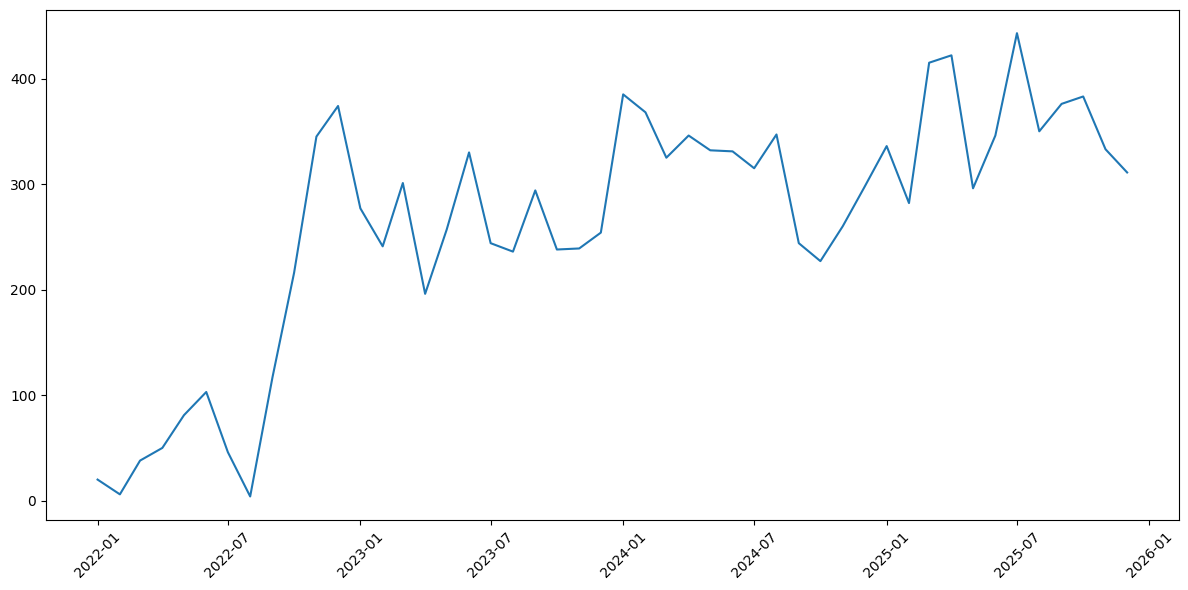

In [32]:
df_disc_over_time = interface.q_to_df("""
    SELECT DATE_TRUNC('month', s.difficulty_date) AS month, COUNT(*) AS discrepancies
    FROM sdr_event AS s
    WHERE LEFT(s.operator_control_number, 4) = 'AALA'
    GROUP BY month ORDER BY month;
""")

plt.figure(figsize=(12,6))
plt.plot(df_disc_over_time['month'], df_disc_over_time['discrepancies'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

I'll include all info from nov 2022 onward to accurately reflect the nature of fleet maintenance for AA as to resolve issues pertaining to lack of SDR's during the SDRS maintenance period from 2021-2022.

In [ ]:
-- view for seeing only aa data from nov 2022 onward
CREATE sdr_event_aa AS
    SELECT *
    FROM sdr_event
    WHERE LEFT(operator_control_number, 4) = 'AALA' AND difficulty_date >= '2022-11-01';

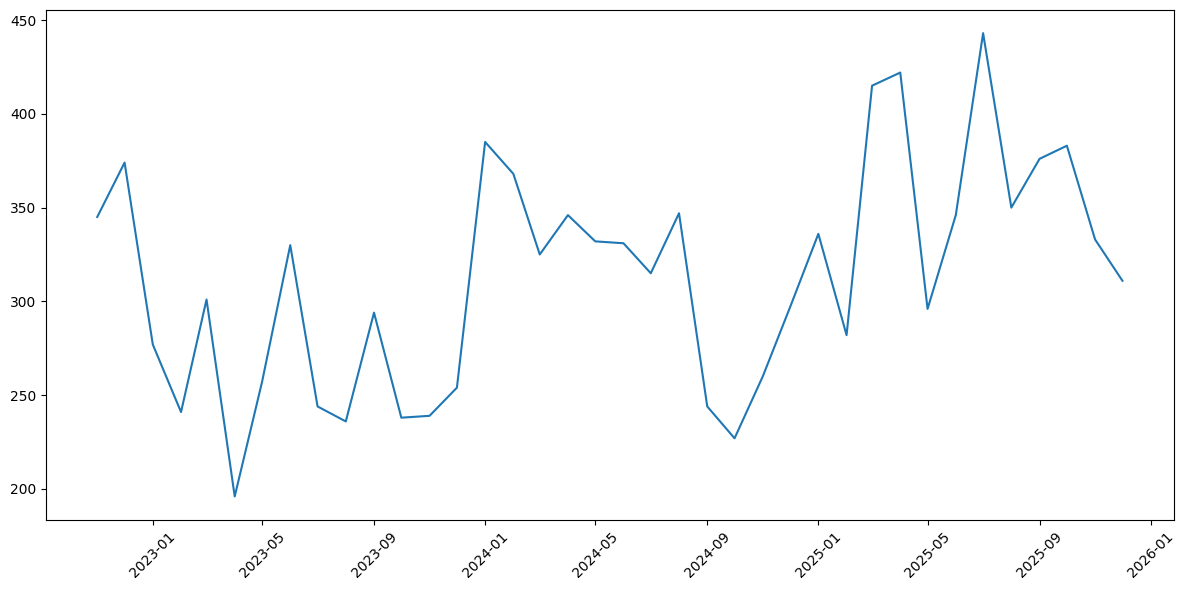

In [33]:
df_disc_over_time = interface.q_to_df("""
    SELECT DATE_TRUNC('month', s.difficulty_date) AS month, COUNT(*) AS discrepancies
    FROM sdr_event_AA AS s
    GROUP BY month ORDER BY month;
""")

plt.figure(figsize=(12,6))
plt.plot(df_disc_over_time['month'], df_disc_over_time['discrepancies'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## ATA/JASC - What systems are failing the most and how?
### ATA Chapters causing safety failures and grounding

In [ ]:
-- Highest ata_chapter safety discrepencies
SELECT a.ata_chapter, a.description, count(DISTINCT s.operator_control_number) AS discrepancies
FROM sdr_event_aa AS s
INNER JOIN jasc_code AS j
    ON j.jasc_code = s.jasc_code
INNER JOIN ata_chapter AS a
    ON a.ata_chapter = j.ata_chapter
GROUP BY a.ata_chapter, a.description
ORDER BY discrepancies DESC;

-- Highest ata_chapter safety discrepencies
-- GROUNDING
SELECT a.ata_chapter, a.description, count(DISTINCT s.operator_control_number) AS grounding_discrepancies
FROM sdr_event_aa AS s
INNER JOIN jasc_code AS j
    ON j.jasc_code = s.jasc_code
INNER JOIN ata_chapter AS a
    ON a.ata_chapter = j.ata_chapter
WHERE s.aog_flag = TRUE
GROUP BY a.ata_chapter, a.description
ORDER BY grounding_discrepancies DESC;

-- AOG/System Safety Failure Rate
-- (How often are systems failing where they result in grounding?)
WITH aog_rate_table AS (
    SELECT a.ata_chapter, a.description, AVG(s.aog_flag::int) AS aog_rate, count(s.aog_flag) total_writeups
    FROM sdr_event_aa AS s
    INNER JOIN jasc_code AS j
        ON j.jasc_code = s.jasc_code
    INNER JOIN ata_chapter AS a
        ON a.ata_chapter = j.ata_chapter
    GROUP BY a.ata_chapter
)

SELECT *
FROM aog_rate_table
ORDER BY aog_rate DESC;

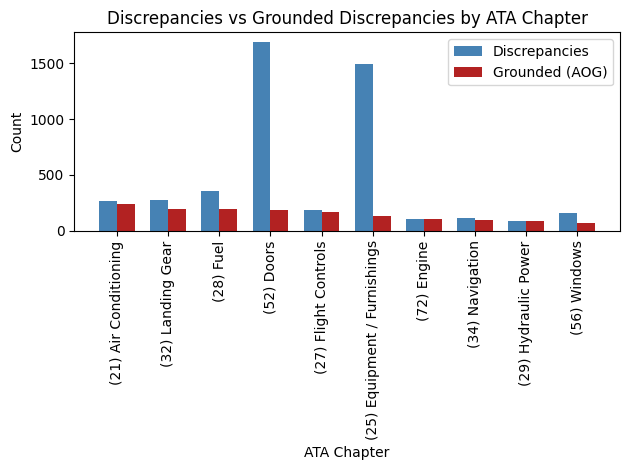

[0 1 2 3 4 5 6 7 8 9]


In [34]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
sys.path.append(os.path.abspath(".."))
from util import sql_python_interface as interface

my_df = interface.q_to_df("""
    -- Highest ata_chapter safety discrepencies
    SELECT a.ata_chapter::varchar, a.description, count(DISTINCT s.operator_control_number) AS discrepancies, SUM(s.aog_flag::int) AS grounding_discrepancies
    FROM sdr_event_aa AS s
    INNER JOIN jasc_code AS j
        ON j.jasc_code = s.jasc_code
    INNER JOIN ata_chapter AS a
        ON a.ata_chapter = j.ata_chapter
    GROUP BY a.ata_chapter, a.descriptioN
    ORDER BY grounding_discrepancies DESC
    LIMIT 10;
""")

x = np.arange(len(my_df))  # positions for each ATA chapter
width = 0.35            # width of each bar

plt.bar(x - width/2, my_df['discrepancies'], width, label='Discrepancies', color='steelblue')
plt.bar(x + width/2, my_df['grounding_discrepancies'], width, label='Grounded (AOG)', color='firebrick')

plt.xticks(x, '(' + my_df['ata_chapter'] + ') ' + my_df['description'], rotation=90)
plt.xlabel("ATA Chapter")
plt.ylabel("Count")
plt.title("Discrepancies vs Grounded Discrepancies by ATA Chapter")
plt.legend()

plt.tight_layout()
plt.show()
print(x)


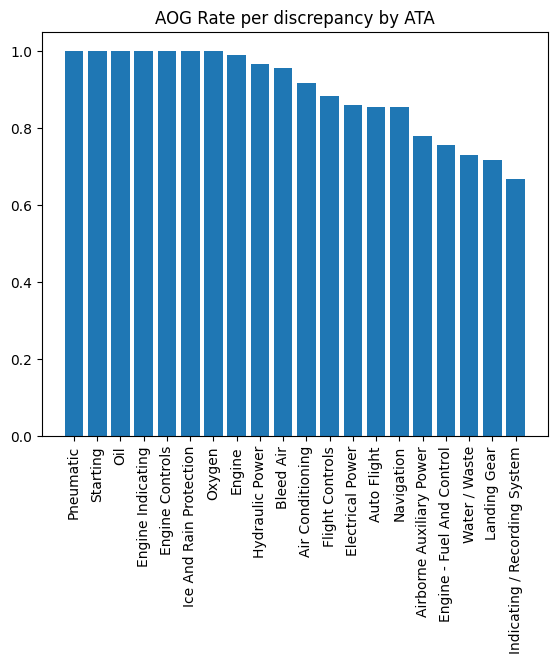

In [35]:
from util import sql_python_interface as interface

my_df = interface.q_to_df("""
    -- AOG/System Safety Failure Rate
    -- (How often are systems failing where they result in grounding?)
    WITH aog_rate_table AS (
        SELECT a.ata_chapter, a.description, AVG(s.aog_flag::int) AS aog_rate, count(s.aog_flag) total_writeups
        FROM sdr_event_aa AS s
        INNER JOIN jasc_code AS j
            ON j.jasc_code = s.jasc_code
        INNER JOIN ata_chapter AS a
            ON a.ata_chapter = j.ata_chapter
        GROUP BY a.ata_chapter
    )

    SELECT *
    FROM aog_rate_table
    ORDER BY aog_rate DESC
    LIMIT 20;
""")

plt.bar(x=my_df['description'], height=my_df['aog_rate'])
plt.title('AOG Rate per discrepancy by ATA')
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

### ATA Chapter Relationship with Operational Disruption Severity

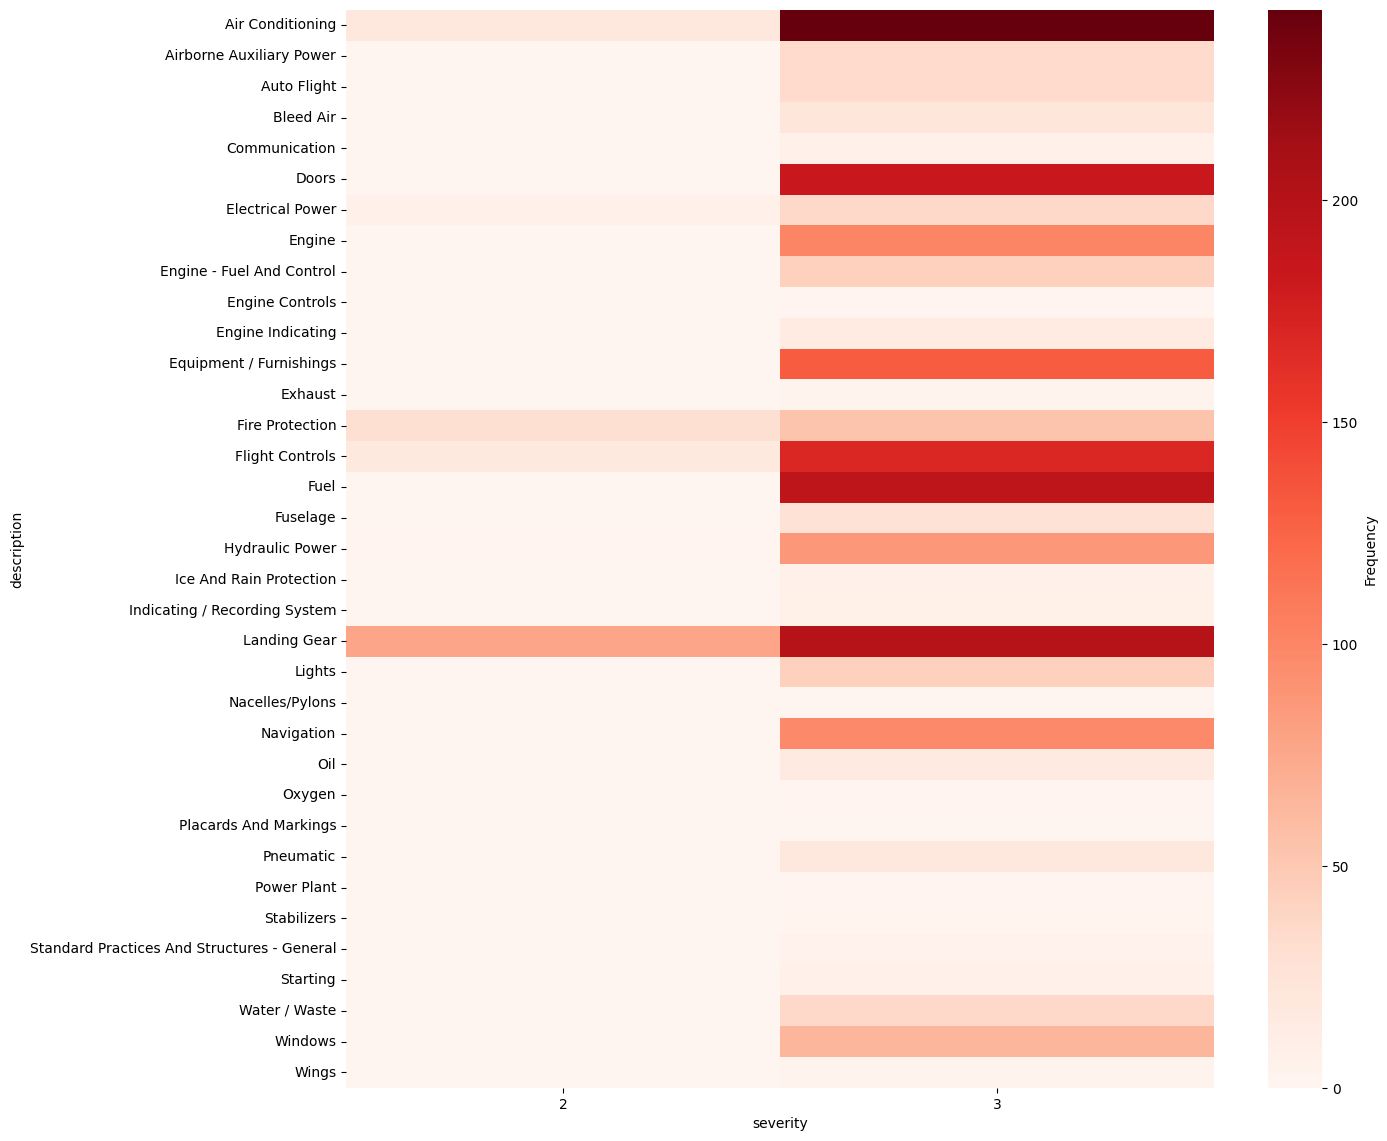

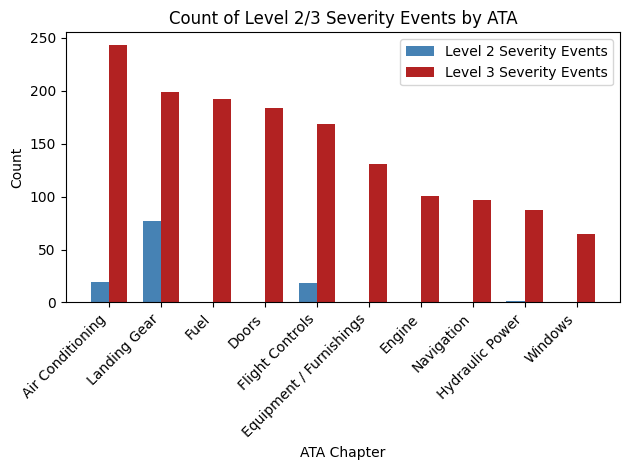

In [97]:
import seaborn as sns

df_sev_freq_ata = interface.q_to_df("""
    SELECT 
    a.ata_chapter,
    a.description,
    s.severity,
    COUNT(s.operator_control_number) AS frequency
FROM sdr_event_aa AS s
INNER JOIN jasc_code AS j
    ON j.jasc_code = s.jasc_code
INNER JOIN ata_chapter AS a
    ON a.ata_chapter = j.ata_chapter
WHERE a.description IS NOT NULL
GROUP BY 
    a.ata_chapter,
    a.description,
    s.severity
ORDER BY 
    s.severity DESC,
    frequency DESC
                  """)

# Pivot the table to be heatmap ready
df_sev_freq_ata.drop(columns=['ata_chapter'], inplace=True)
df_sev_freq_ata = df_sev_freq_ata.pivot(columns='severity', index='description', values='frequency').astype(float)
df_sev_freq_ata.drop(columns=[0, 1], inplace=True)
df_sev_freq_ata = df_sev_freq_ata.fillna(0.0)


# Plot the heatmap
plt.figure(figsize=(14, 14))
plt_sev_freq_ata = sns.heatmap(
    df_sev_freq_ata,
    cmap='Reds',
    cbar_kws={"label": "Frequency"}
)

plt.show()

# Sort values by severity 3 for identifying highest AOG drivers
df_sev_freq_ata.sort_values(by=3, ascending=False, inplace=True)
df_sev_freq_ata = df_sev_freq_ata[0:10]

# PLOT BAR GRAPH OF SEV 2/3 DRIVERS BY VOLUME OF DISC
x = np.arange(len(df_sev_freq_ata))  # positions for each ATA chapter
width = 0.35

plt.bar(x - width/2, df_sev_freq_ata[2], width, label='Level 2 Severity Events', color='steelblue')
plt.bar(x + width/2, df_sev_freq_ata[3], width, label='Level 3 Severity Events', color='firebrick')

plt.xticks(x, labels=df_sev_freq_ata.index, rotation=45, ha='right')
plt.xlabel("ATA Chapter")
plt.ylabel("Count")
plt.title("Count of Level 2/3 Severity Events by ATA")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
SELECT *
FROM sdr_event_aa
LIMIT 10;

SELECT severity, discrepancy
FROM sdr_event_aa
WHERE LEFT(jasc_code::varchar, 2) = '21';

SyntaxError: invalid syntax (676163708.py, line 1)

### JASCs causing safety failures and grounding

In [36]:
-- Determine highest ata_chapters discrepency occurances
SELECT j.jasc_code, j.description, count(DISTINCT s.operator_control_number) AS discrepancies
FROM sdr_event_aa AS s
INNER JOIN jasc_code AS j
    ON j.jasc_code = s.jasc_code
GROUP BY j.jasc_code, j.description
ORDER BY discrepancies DESC;

-- Determine highest ata_chapters discrepency occurances
-- BY GROUNDING
SELECT j.jasc_code, j.description, count(DISTINCT s.operator_control_number) AS grounding_discrepancies
FROM sdr_event_aa AS s
INNER JOIN jasc_code AS j
    ON j.jasc_code = s.jasc_code
WHERE s.aog_flag = True
GROUP BY j.jasc_code, j.description
ORDER BY grounding_discrepancies DESC;

-- AOG/Subsystem Safety Failure Rate
-- (How often are subsystems failing where they result in grounding?)
WITH aog_rate_table AS (
    SELECT j.jasc_code, j.description, AVG(s.aog_flag::int) AS aog_rate, COUNT(s.aog_flag) AS total_writeups
    FROM sdr_event_aa AS s
    INNER JOIN jasc_code AS j
        ON j.jasc_code = s.jasc_code
    GROUP BY j.jasc_code
)

SELECT *
FROM aog_rate_table
ORDER BY aog_rate DESC;

SyntaxError: invalid syntax (2431476427.py, line 1)

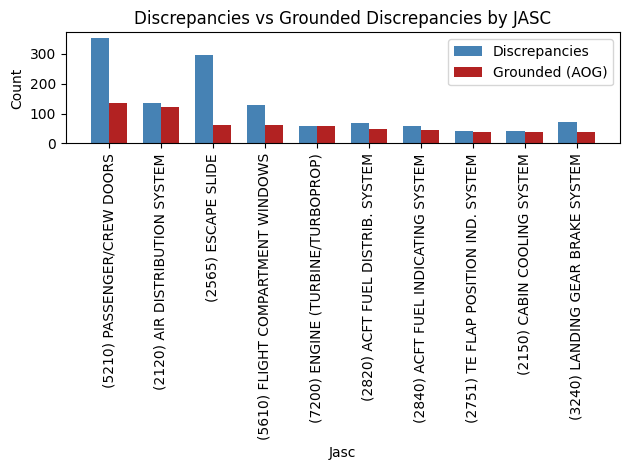

[0 1 2 3 4 5 6 7 8 9]


In [37]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
sys.path.append(os.path.abspath(".."))
from util import sql_python_interface as interface

my_df = interface.q_to_df("""
    -- Highest ata_chapter safety discrepencies
    SELECT j.jasc_code::varchar, j.description, count(DISTINCT s.operator_control_number) AS discrepancies, SUM(s.aog_flag::int) AS grounding_discrepancies
    FROM sdr_event_aa AS s
    INNER JOIN jasc_code AS j
        ON j.jasc_code = s.jasc_code
    GROUP BY j.jasc_code, j.description
    ORDER BY grounding_discrepancies DESC
    LIMIT 10;
""")

x = np.arange(len(my_df))  # positions for each ATA chapter
width = 0.35            # width of each bar

plt.bar(x - width/2, my_df['discrepancies'], width, label='Discrepancies', color='steelblue')
plt.bar(x + width/2, my_df['grounding_discrepancies'], width, label='Grounded (AOG)', color='firebrick')

plt.xticks(x, '(' + my_df['jasc_code'] + ') ' + my_df['description'], rotation=90)
plt.xlabel("Jasc")
plt.ylabel("Count")
plt.title("Discrepancies vs Grounded Discrepancies by JASC")
plt.legend()

plt.tight_layout()
plt.show()
print(x)


## Trend Analysis
### Events per month by ATA and JASC

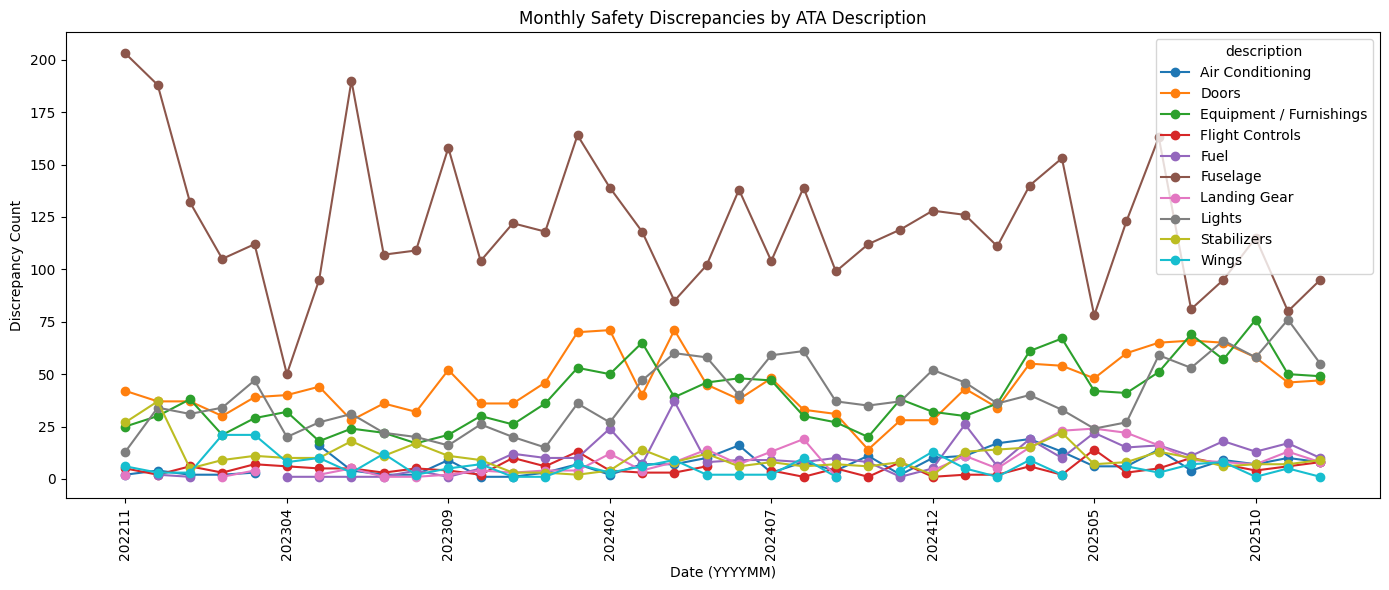

In [38]:
my_df = interface.q_to_df("""
    WITH monthly_counts AS (
    SELECT 
        a.description,
        TO_CHAR(s.difficulty_date, 'YYYYMM') AS date,
        COUNT(s.operator_control_number) AS count
    FROM sdr_event_aa AS s
    INNER JOIN jasc_code AS j
        ON j.jasc_code = s.jasc_code
    INNER JOIN ata_chapter AS a
        ON j.ata_chapter = a.ata_chapter
    GROUP BY a.description, date
),

total_counts AS (
    SELECT 
        description,
        SUM(count) AS total_count
    FROM monthly_counts
    GROUP BY description
),

top_descriptions AS (
    SELECT 
        description
    FROM total_counts
    ORDER BY total_count DESC
    LIMIT 10
)

SELECT 
    m.description,
    m.date,
    m.count
FROM monthly_counts AS m
WHERE m.description IN (SELECT description FROM top_descriptions)
ORDER BY m.date ASC, m.count DESC;
""")


pivot_df = my_df.pivot(
    index='date',
    columns='description',
    values='count'
)

pivot_df.plot(
    figsize=(14, 6),
    marker='o'
)

plt.title("Monthly Safety Discrepancies by ATA Description")
plt.xlabel("Date (YYYYMM)")
plt.ylabel("Discrepancy Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### AOG events over time

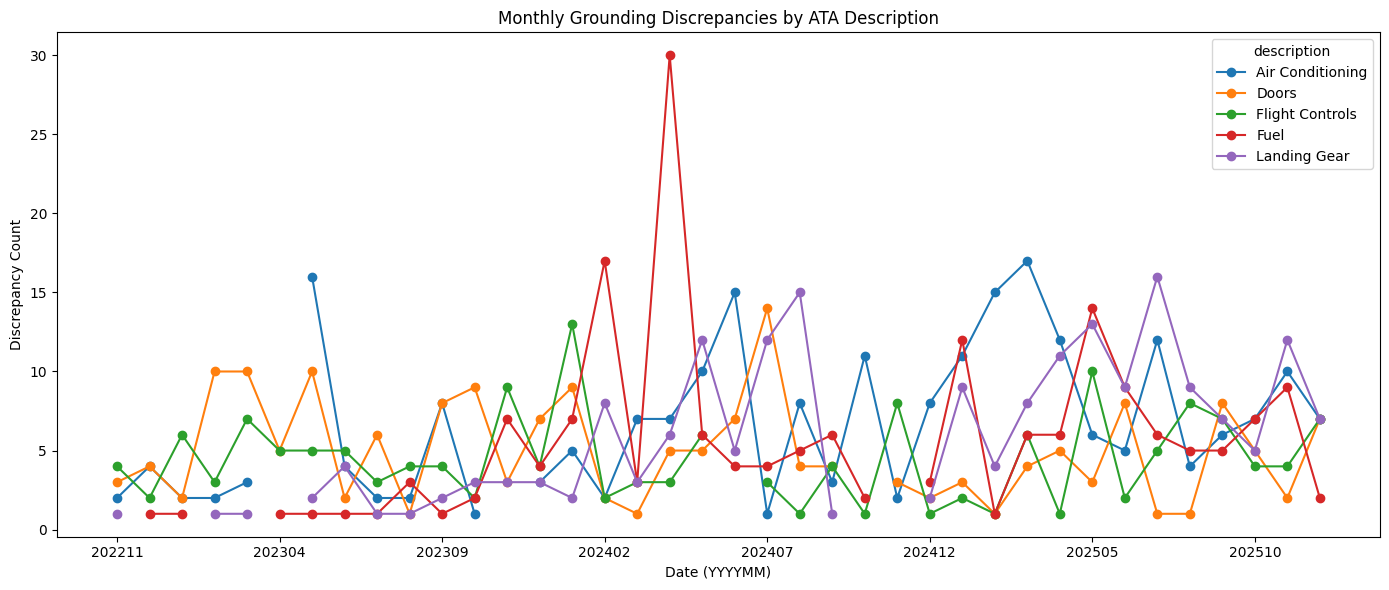

In [39]:
my_df = interface.q_to_df("""
    WITH monthly_counts AS (
    SELECT 
        a.description,
        TO_CHAR(s.difficulty_date, 'YYYYMM') AS date,
        COUNT(s.operator_control_number) AS count
    FROM sdr_event_aa AS s
    INNER JOIN jasc_code AS j
        ON j.jasc_code = s.jasc_code
    INNER JOIN ata_chapter AS a
        ON j.ata_chapter = a.ata_chapter
    WHERE aog_flag::int = 1
    GROUP BY a.description, date
),

total_counts AS (
    SELECT 
        description,
        SUM(count) AS total_count
    FROM monthly_counts
    GROUP BY description
),

top_descriptions AS (
    SELECT 
        description
    FROM total_counts
    ORDER BY total_count DESC
    LIMIT 5
)

SELECT 
    m.description,
    m.date,
    m.count
FROM monthly_counts AS m
WHERE m.description IN (SELECT description FROM top_descriptions)
ORDER BY m.date ASC, m.count DESC;
""")


pivot_df = my_df.pivot(
    index='date',
    columns='description',
    values='count'
)

pivot_df.plot(
    figsize=(14, 6),
    marker='o'
)

plt.title("Monthly Grounding Discrepancies by ATA Description")
plt.xlabel("Date (YYYYMM)")
plt.ylabel("Discrepancy Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Failure Mode Analysis
### Keyword frequency

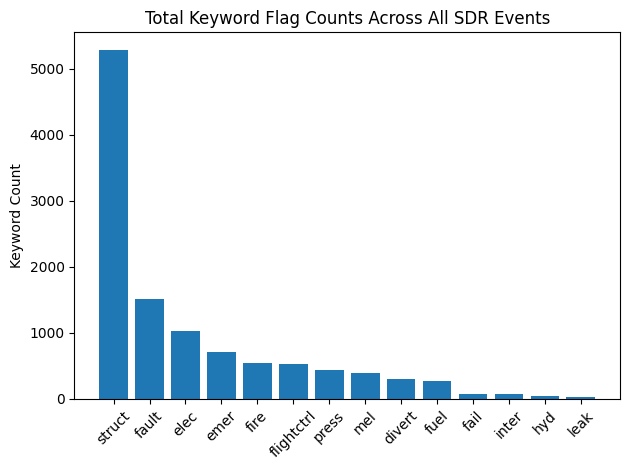

In [40]:
import os
import sys
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath(".."))
from util import sql_python_interface as interface
my_df = interface.q_to_df("""
                        SELECT
                                SUM(s.emer_flag::int) AS emer,
                                SUM(s.divert_flag::int) AS divert,
                                SUM(s.fail_flag::int) AS fail,
                                SUM(s.fault_flag::int) AS fault,
                                SUM(s.inter_flag::int) AS inter,
                                SUM(s.fire_flag::int) AS fire,
                                SUM(s.leak_flag::int) AS leak,
                                SUM(s.press_flag::int) AS press,
                                SUM(s.elec_flag::int) AS elec,
                                SUM(s.fuel_flag::int) AS fuel,
                                SUM(s.hyd_flag::int) AS hyd,
                                SUM(s.flightctrl_flag::int) AS flightctrl,
                                SUM(s.struct_flag::int) AS struct,
                                SUM(s.mel_flag::int) AS mel
                        FROM sdr_event_aa AS s;
                          """)

# Convert the single row into a Series
my_series = my_df.iloc[0]
my_series = my_series.sort_values(ascending=False)

# Plot
plt.bar(my_series.index, my_series.values)
plt.xticks(rotation=45)
plt.ylabel("Keyword Count")
plt.title("Total Keyword Flag Counts Across All SDR Events")
plt.tight_layout()
plt.show()


### Keyword x ATA Heatmap

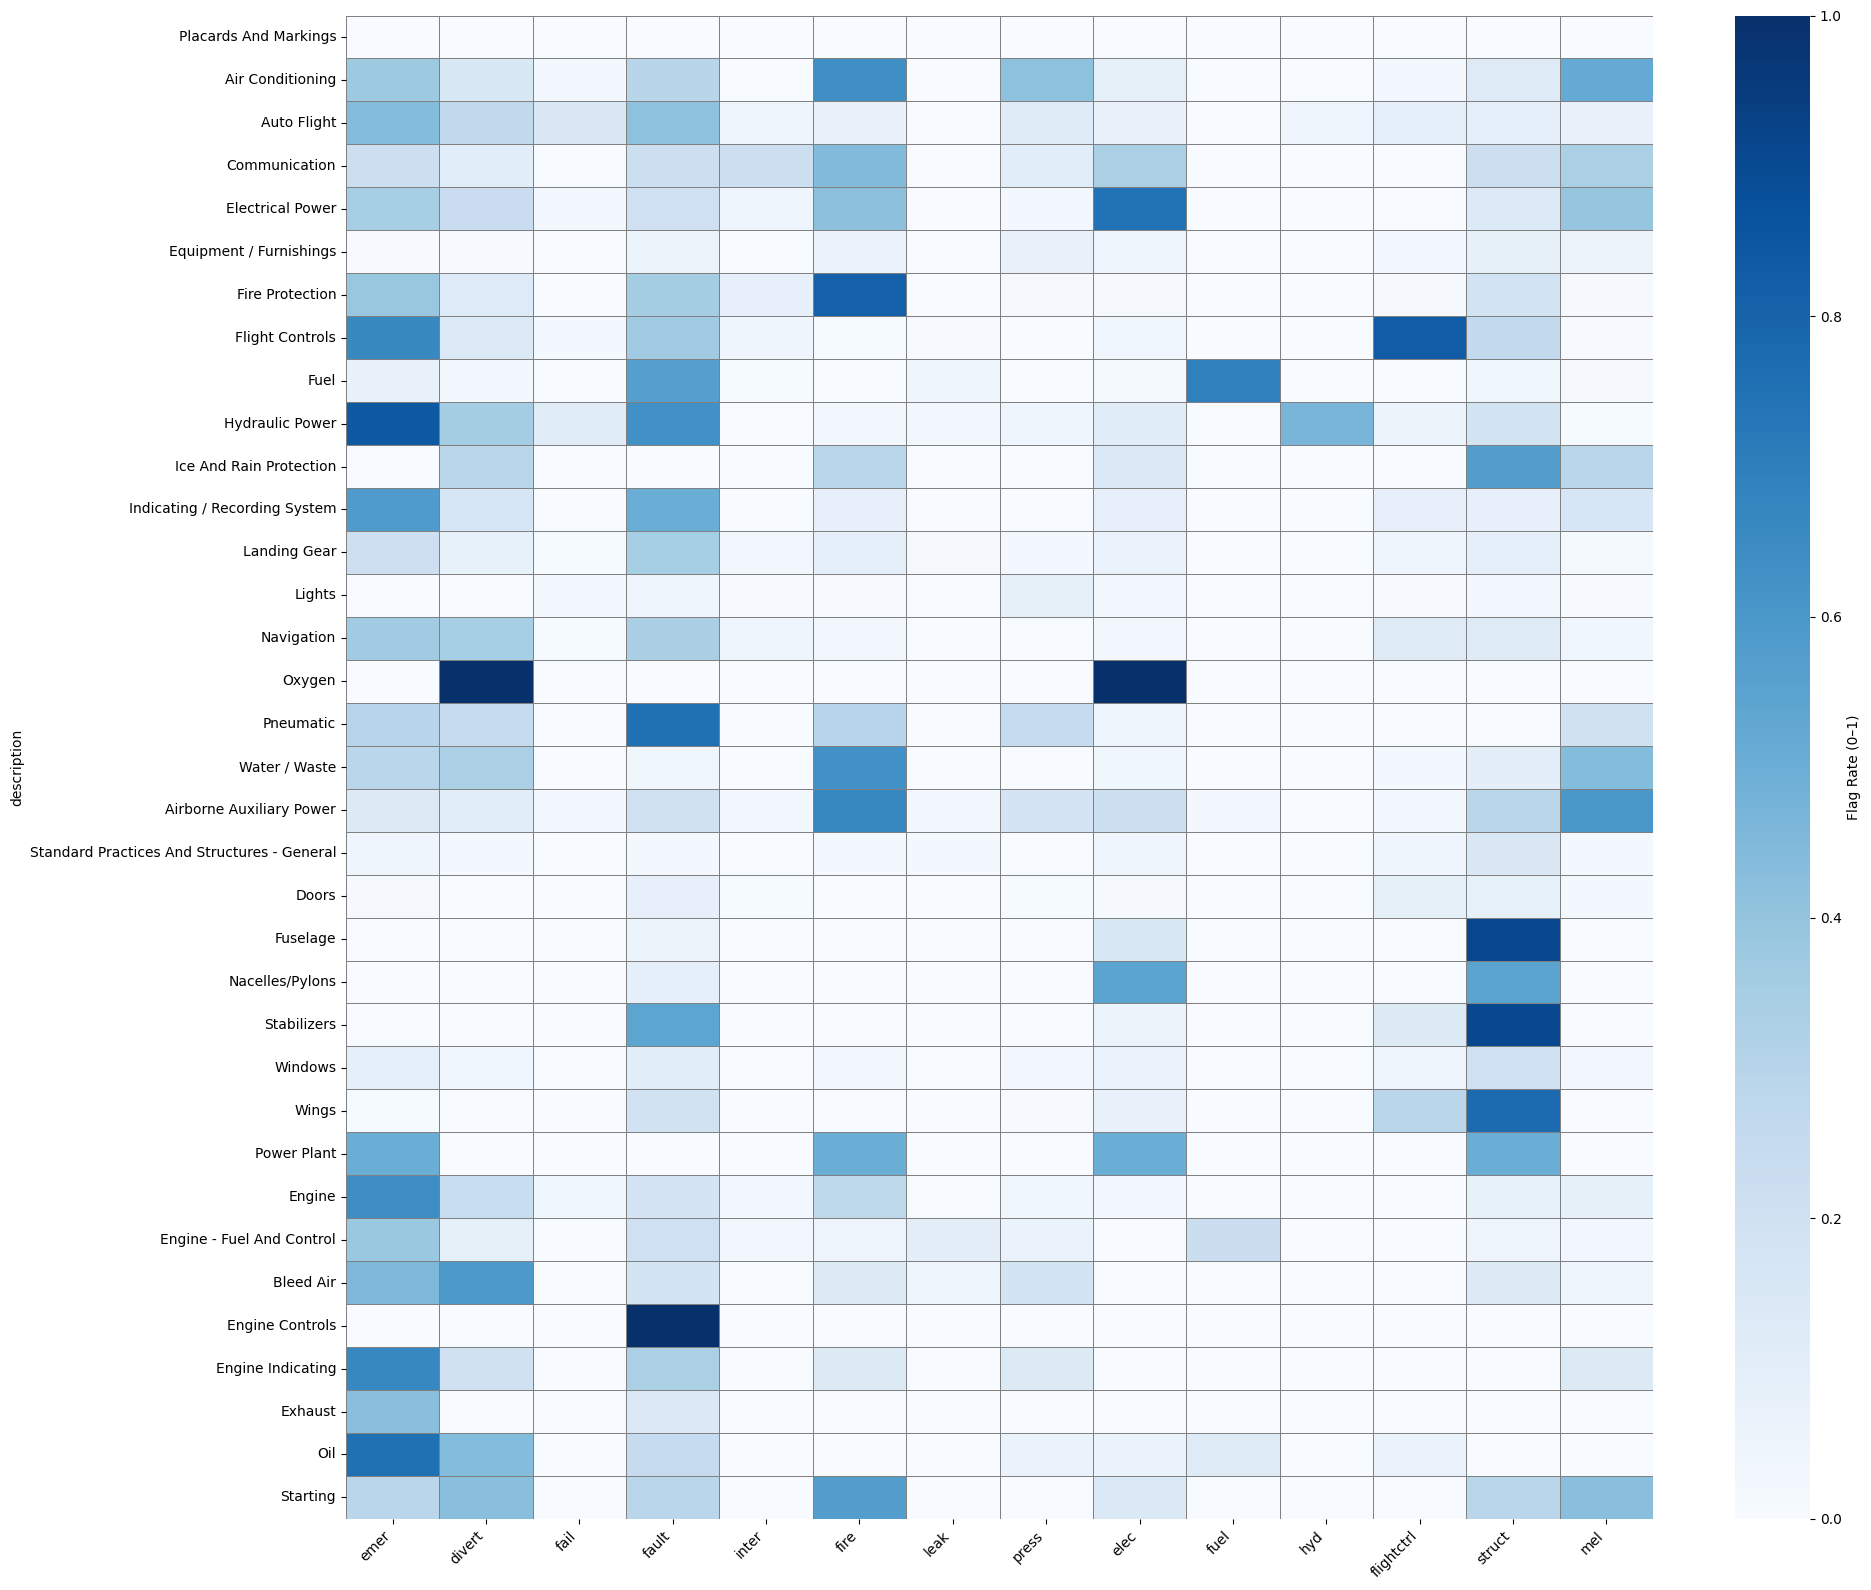

In [41]:
import os
import sys
sys.path.append(os.path.abspath(".."))
from util import sql_python_interface as interface
my_df = interface.q_to_df("""
                        SELECT  a.description,
                                AVG(s.emer_flag::int) AS emer,
                                AVG(s.divert_flag::int) AS divert,
                                AVG(s.fail_flag::int) AS fail,
                                AVG(s.fault_flag::int) AS fault,
                                AVG(s.inter_flag::int) AS inter,
                                AVG(s.fire_flag::int) AS fire,
                                AVG(s.leak_flag::int) AS leak,
                                AVG(s.press_flag::int) AS press,
                                AVG(s.elec_flag::int) AS elec,
                                AVG(s.fuel_flag::int) AS fuel,
                                AVG(s.hyd_flag::int) AS hyd,
                                AVG(s.flightctrl_flag::int) AS flightctrl,
                                AVG(s.struct_flag::int) AS struct,
                                AVG(s.mel_flag::int) AS mel
                        FROM sdr_event_aa AS s
                        INNER JOIN jasc_code AS j
                                ON j.jasc_code = s.jasc_code
                        INNER JOIN ata_chapter AS a
                                ON j.ata_chapter = a.ata_chapter
                        GROUP BY a.ata_chapter
                        ORDER BY a.ata_chapter::int ASC;
                          """)

df_keyword_heatmap = my_df.set_index('description').astype(float)

plt.figure(figsize=(20, 16))  # ← make the plot MUCH bigger BEFORE drawing

ax = sns.heatmap(
    df_keyword_heatmap,
    cmap="Blues",
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={"label": "Flag Rate (0–1)"}
)

# Rotate x-labels so they never overlap
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Ensure y-labels are fully visible
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

# Expand margins so labels never get cut off
plt.subplots_adjust(
    left=0.35,   # more room for long ATA descriptions
    bottom=0.25, # more room for rotated x-labels
    right=0.95,
    top=0.95
)

plt.tight_layout()
plt.show()

### Keyword x Severity

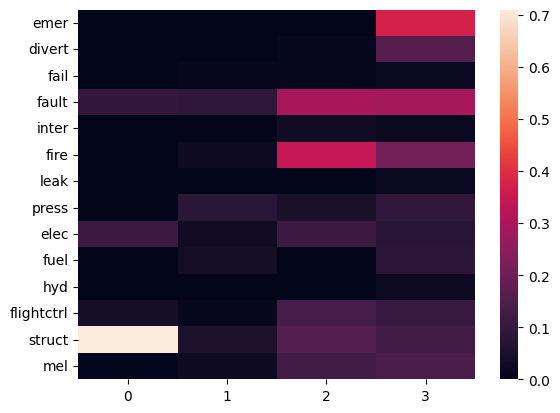

In [42]:
df_keyword_severity_heatmap = interface.q_to_df(
    """
    SELECT  
            AVG(s.emer_flag::int)::float AS emer,
            AVG(s.divert_flag::int)::float AS divert,
            AVG(s.fail_flag::int)::float AS fail,
            AVG(s.fault_flag::int)::float AS fault,
            AVG(s.inter_flag::int)::float AS inter,
            AVG(s.fire_flag::int)::float AS fire,
            AVG(s.leak_flag::int)::float AS leak,
            AVG(s.press_flag::int)::float AS press,
            AVG(s.elec_flag::int)::float AS elec,
            AVG(s.fuel_flag::int)::float AS fuel,
            AVG(s.hyd_flag::int)::float AS hyd,
            AVG(s.flightctrl_flag::int)::float AS flightctrl,
            AVG(s.struct_flag::int)::float AS struct,
            AVG(s.mel_flag::int)::float AS mel
    FROM sdr_event_aa AS s
    GROUP BY s.severity
    ORDER BY s.severity ASC;
    """)


sns.heatmap(df_keyword_severity_heatmap.transpose())
plt.show()

SyntaxError: invalid syntax (2233533361.py, line 1)

In [43]:
df_events_aircraft = interface.q_to_df(
    """
    SELECT COUNT(s.id) AS discrepancies, a.registry_n_number, o.name
    FROM aircraft AS a
        INNER JOIN sdr_event_aa AS s
            ON s.aircraft_id = a.id
        INNER JOIN operator AS o
            ON s.operator_id = o.id
    GROUP BY a.registry_n_number, o.name
    ORDER BY discrepancies DESC
    LIMIT 50;
    """
)

df_events_aircraft

,discrepancies,registry_n_number,name
0,115,905AN,AMERICAN AIRLINES INC.
1,113,903AN,AMERICAN AIRLINES INC.
2,103,928AN,AMERICAN AIRLINES INC.
3,102,906AN,AMERICAN AIRLINES INC.
4,99,912AN,AMERICAN AIRLINES INC.
5,95,910AN,AMERICAN AIRLINES INC.
6,93,920AN,AMERICAN AIRLINES INC.
7,82,934AN,AMERICAN AIRLINES INC.
8,81,909AN,AMERICAN AIRLINES INC.
9,80,908AN,AMERICAN AIRLINES INC.


### AOG per aircraft

In [ ]:
-- events by airline
SELECT o.name, o.sdr_prefix, count(s.operator_control_number) as disc, sum(s.aog_flag::int) as gnd_disc
FROM sdr_event_aa as s
inner join operator as o
    on s.operator_id = o.id
group by o.name, o.sdr_prefix
order by gnd_disc desc;

SyntaxError: invalid syntax (217289171.py, line 1)

In [ ]:
    SELECT COUNT(s.id) AS discrepancies, o.name
    FROM sdr_event AS s
    INNER JOIN operator AS o
        ON s.operator_id = o.id
    WHERE s.aog_flag = True
    GROUP BY o.name
    ORDER BY discrepancies DESC;

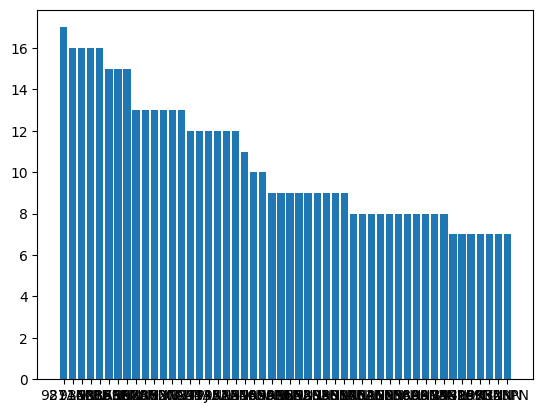

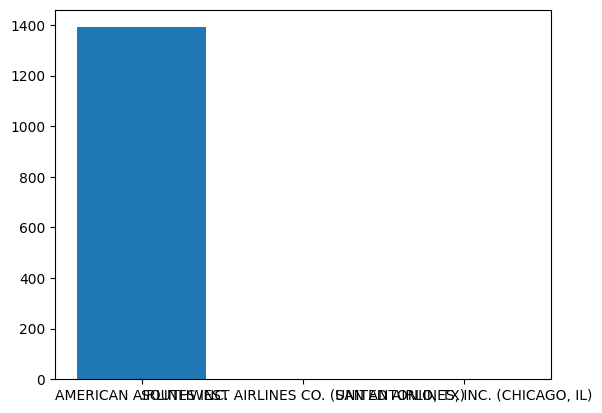

   discrepancies                                      name
0           1391                    AMERICAN AIRLINES INC.
1              2  SOUTHWEST AIRLINES CO. (SAN ANTONIO, TX)
2              1       UNITED AIRLINES, INC. (CHICAGO, IL)
    discrepancies registry_n_number                    name
0              17             921AN  AMERICAN AIRLINES INC.
1              16             871NN  AMERICAN AIRLINES INC.
2              16             916NN  AMERICAN AIRLINES INC.
3              16             342RX  AMERICAN AIRLINES INC.
4              16             933AN  AMERICAN AIRLINES INC.
5              15             815NN  AMERICAN AIRLINES INC.
6              15             869NN  AMERICAN AIRLINES INC.
7              15             832NN  AMERICAN AIRLINES INC.
8              13             967AN  AMERICAN AIRLINES INC.
9              13             970NN  AMERICAN AIRLINES INC.
10             13             887NN  AMERICAN AIRLINES INC.
11             13             862NN  AMERICA

In [20]:
df_aog_events_aircraft = interface.q_to_df(
    """
    SELECT COUNT(s.id) AS discrepancies, a.registry_n_number, o.name
    FROM aircraft AS a
        INNER JOIN sdr_event AS s
            ON s.aircraft_id = a.id
        INNER JOIN operator AS o
            ON s.operator_id = o.id
    WHERE s.aog_flag = True
    GROUP BY a.registry_n_number, o.name
    ORDER BY discrepancies DESC
    LIMIT 50;
    """
)

df_aog_events_airline = interface.q_to_df(
    """
    SELECT COUNT(s.id) AS discrepancies, o.name
    FROM sdr_event AS s
    INNER JOIN operator AS o
        ON s.operator_id = o.id
    WHERE s.aog_flag = True
    GROUP BY o.id
    ORDER BY discrepancies DESC;
    """
)

df_aog_events_aircraft

plt.bar(x=df_aog_events_aircraft['registry_n_number'], height=df_aog_events_aircraft['discrepancies'])
plt.show()

plt.bar(x=df_aog_events_airline['name'], height=df_aog_events_airline['discrepancies'])
plt.show()
print(df_aog_events_airline)
print(df_aog_events_aircraft)

## Component-Level Analysis

In [ ]:
WITH sev3 AS (
        SELECT
            s.operator_control_number,
            s.severity,
            s.discrepancy,
            s.part_number,
            s.part_name
        FROM sdr_event_aa AS s
        WHERE s.severity = 3
    ),

    part_types AS (
        SELECT
            operator_control_number,
            severity,
            part_number,
            part_name,
            discrepancy,

            CASE
                WHEN discrepancy ILIKE '%could not duplicate%'
                  OR discrepancy ILIKE '%unable to determine%'
                  OR discrepancy ILIKE '%no fault%'
                  OR discrepancy ILIKE '%no defects%'
                  OR discrepancy ILIKE '%no evidence%'
                  OR discrepancy ILIKE '%not determine%'
                  OR discrepancy ILIKE '%open%'
                  THEN 'CND'
                WHEN part_name ILIKE '%engine%' OR discrepancy ILIKE '%replaced%engine%' THEN 'engine'
                WHEN part_name ILIKE '%window%' OR discrepancy ILIKE '%window%' THEN 'window'
                WHEN part_name ILIKE '%oven%' OR discrepancy ILIKE '%oven%' THEN 'oven'
                WHEN part_name ILIKE '%windshield%' OR discrepancy ILIKE '%windshield%' THEN 'window'
                WHEN part_name ILIKE '%compensator%' OR discrepancy ILIKE '%compensator%' THEN 'compensator'
                WHEN part_name ILIKE '%control unit%' OR discrepancy ILIKE '%control unit%' THEN 'control unit'
                WHEN part_name ILIKE '%valve%' OR discrepancy ILIKE '%valve%' THEN 'valve'
                WHEN part_name ILIKE '%acm%' OR discrepancy ILIKE '%acm%' THEN 'acm'
                WHEN part_name ILIKE '%duct%' OR discrepancy ILIKE '%duct%' THEN 'duct'
                WHEN part_name ILIKE '%regulator%' OR discrepancy ILIKE '%regulator%' THEN 'regulator'
                WHEN part_name ILIKE '%manifold%' OR discrepancy ILIKE '%manifold%' THEN 'manifold'
                WHEN part_name ILIKE '%bleed%' OR discrepancy ILIKE '%bleed%' THEN 'bleed air component'
                WHEN part_name ILIKE '%pack%' OR discrepancy ILIKE '%pack%' THEN 'pack'
                WHEN part_name ILIKE '%relay%' OR discrepancy ILIKE '%relay%' THEN 'relay'
                WHEN part_name ILIKE '%switch%' OR discrepancy ILIKE '%switch%' THEN 'switch'
                WHEN part_name ILIKE '%breaker%' OR discrepancy ILIKE '%breaker%' THEN 'circuit breaker'
                WHEN part_name ILIKE '%generator%' OR discrepancy ILIKE '%generator%' THEN 'generator'
                WHEN part_name ILIKE '%battery%' OR discrepancy ILIKE '%battery%' THEN 'battery'
                WHEN part_name ILIKE '%sensor%' OR discrepancy ILIKE '%sensor%' THEN 'sensor'
                WHEN part_name ILIKE '%probe%' OR discrepancy ILIKE '%probe%' THEN 'probe'
                WHEN part_name ILIKE '%transducer%' OR discrepancy ILIKE '%transducer%' THEN 'transducer'
                WHEN part_name ILIKE '%antenna%' OR discrepancy ILIKE '%antenna%' THEN 'antenna'
                WHEN part_name ILIKE '%controller%' OR discrepancy ILIKE '%controller%' THEN 'controller'
                WHEN part_name ILIKE '%computer%' OR discrepancy ILIKE '%computer%' THEN 'computer'
                WHEN part_name ILIKE '%module%' OR discrepancy ILIKE '%module%' THEN 'module'
                WHEN part_name ILIKE '%actuator%' OR discrepancy ILIKE '%actuator%' THEN 'actuator'
                WHEN part_name ILIKE '%servo%' OR discrepancy ILIKE '%servo%' THEN 'servo'
                WHEN part_name ILIKE '%rod%' OR discrepancy ILIKE '%rod%' THEN 'control rod'
                WHEN part_name ILIKE '%hinge%' OR discrepancy ILIKE '%hinge%' THEN 'hinge'
                WHEN part_name ILIKE '%pump%' OR discrepancy ILIKE '%pump%' THEN 'pump'
                WHEN part_name ILIKE '%reservoir%' OR discrepancy ILIKE '%reservoir%' THEN 'reservoir'
                WHEN part_name ILIKE '%accumulator%' OR discrepancy ILIKE '%accumulator%' THEN 'accumulator'
                WHEN part_name ILIKE '%strut%' OR discrepancy ILIKE '%strut%' THEN 'strut'
                WHEN part_name ILIKE '%brake%' OR discrepancy ILIKE '%brake%' THEN 'brake'
                WHEN part_name ILIKE '%wheel%' OR discrepancy ILIKE '%wheel%' THEN 'wheel'
                WHEN part_name ILIKE '%tire%' OR discrepancy ILIKE '%tire%' THEN 'tire'
                WHEN part_name ILIKE '%panel%' OR discrepancy ILIKE '%panel%' THEN 'panel'
                WHEN part_name ILIKE '%latch%' OR discrepancy ILIKE '%latch%' THEN 'latch'
                WHEN part_name ILIKE '%door%' OR discrepancy ILIKE '%door%' THEN 'door'
                WHEN part_name ILIKE '%fan%' OR discrepancy ILIKE '%fan%' THEN 'fan'
                WHEN part_name ILIKE '%filter%' OR discrepancy ILIKE '%filter%' THEN 'filter'
                WHEN part_name ILIKE '%heater%' OR discrepancy ILIKE '%heater%' THEN 'heater'
                WHEN part_name ILIKE '%starter%' OR discrepancy ILIKE '%starter%' THEN 'starter'
                WHEN part_name ILIKE '%apu%' OR discrepancy ILIKE '%apu%' THEN 'apu component'
                -- WHEN part_name ILIKE '%light%' OR discrepancy ILIKE '%light%' THEN 'light' --(JUST INDICATION FOR GROUNDING WRITEUP!!!)
                ELSE 'other'
            END AS part_type

        FROM sev3
    ),

    my_table AS (
        SELECT
            discrepancy,
            part_type
        FROM part_types
    )

    SELECT *
    FROM my_table
    WHERE part_type = 'other';

      part_type  event_count
0           CND          442
2        engine          187
3          door          182
4         valve           83
5        window           72
6        switch           68
7        sensor           64
8   compensator           43
9          pack           38
10        probe           37


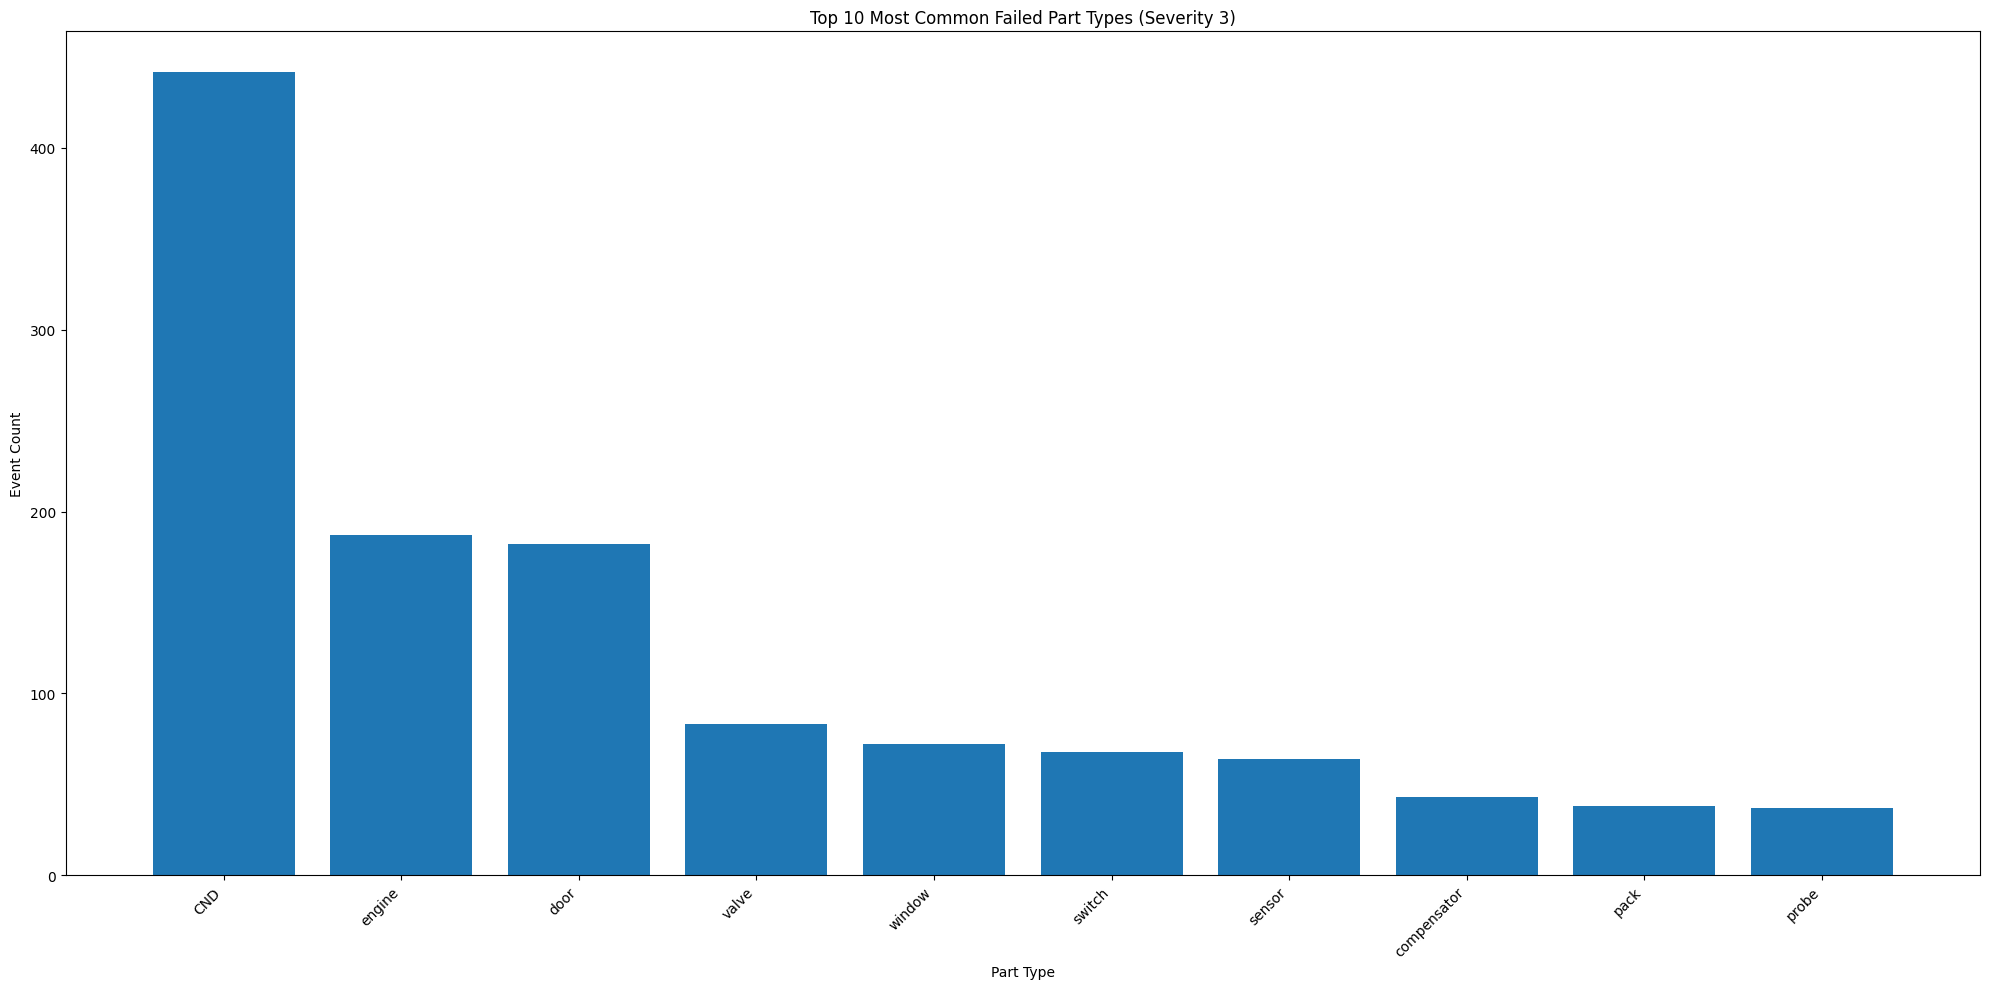

In [ ]:
my_df = interface.q_to_df("""
WITH sev3 AS (
        SELECT
            s.operator_control_number,
            s.severity,
            s.discrepancy,
            s.part_number,
            s.part_name
        FROM sdr_event_aa AS s
        WHERE s.severity = 3
    ),

    part_types AS (
        SELECT
            operator_control_number,
            severity,
            part_number,
            part_name,
            discrepancy,

            CASE
                WHEN discrepancy ILIKE '%could not duplicate%'
                  OR discrepancy ILIKE '%unable to determine%'
                  OR discrepancy ILIKE '%no fault%'
                  OR discrepancy ILIKE '%no defects%'
                  OR discrepancy ILIKE '%no evidence%'
                  OR discrepancy ILIKE '%not determine%'
                  OR discrepancy LIKE '%(OPEN)%'
                  THEN 'CND'
                WHEN part_name ILIKE '%engine%' OR discrepancy ILIKE '%replaced%engine%' THEN 'engine'
                WHEN part_name ILIKE '%window%' OR discrepancy ILIKE '%window%' THEN 'window'
                WHEN part_name ILIKE '%oven%' OR discrepancy ILIKE '%oven%' THEN 'oven'
                WHEN part_name ILIKE '%windshield%' OR discrepancy ILIKE '%windshield%' THEN 'window'
                WHEN part_name ILIKE '%compensator%' OR discrepancy ILIKE '%compensator%' THEN 'compensator'
                WHEN part_name ILIKE '%control unit%' OR discrepancy ILIKE '%control unit%' THEN 'control unit'
                WHEN part_name ILIKE '%valve%' OR discrepancy ILIKE '%valve%' THEN 'valve'
                WHEN part_name ILIKE '%acm%' OR discrepancy ILIKE '%acm%' THEN 'acm'
                WHEN part_name ILIKE '%duct%' OR discrepancy ILIKE '%duct%' THEN 'duct'
                WHEN part_name ILIKE '%regulator%' OR discrepancy ILIKE '%regulator%' THEN 'regulator'
                WHEN part_name ILIKE '%manifold%' OR discrepancy ILIKE '%manifold%' THEN 'manifold'
                WHEN part_name ILIKE '%bleed%' OR discrepancy ILIKE '%bleed%' THEN 'bleed air component'
                WHEN part_name ILIKE '%pack%' OR discrepancy ILIKE '%pack%' THEN 'pack'
                WHEN part_name ILIKE '%relay%' OR discrepancy ILIKE '%relay%' THEN 'relay'
                WHEN part_name ILIKE '%switch%' OR discrepancy ILIKE '%switch%' THEN 'switch'
                WHEN part_name ILIKE '%breaker%' OR discrepancy ILIKE '%breaker%' THEN 'circuit breaker'
                WHEN part_name ILIKE '%generator%' OR discrepancy ILIKE '%generator%' THEN 'generator'
                WHEN part_name ILIKE '%battery%' OR discrepancy ILIKE '%battery%' THEN 'battery'
                WHEN part_name ILIKE '%sensor%' OR discrepancy ILIKE '%sensor%' THEN 'sensor'
                WHEN part_name ILIKE '%probe%' OR discrepancy ILIKE '%probe%' THEN 'probe'
                WHEN part_name ILIKE '%transducer%' OR discrepancy ILIKE '%transducer%' THEN 'transducer'
                WHEN part_name ILIKE '%antenna%' OR discrepancy ILIKE '%antenna%' THEN 'antenna'
                WHEN part_name ILIKE '%controller%' OR discrepancy ILIKE '%controller%' THEN 'controller'
                WHEN part_name ILIKE '%computer%' OR discrepancy ILIKE '%computer%' THEN 'computer'
                WHEN part_name ILIKE '%module%' OR discrepancy ILIKE '%module%' THEN 'module'
                WHEN part_name ILIKE '%actuator%' OR discrepancy ILIKE '%actuator%' THEN 'actuator'
                WHEN part_name ILIKE '%servo%' OR discrepancy ILIKE '%servo%' THEN 'servo'
                WHEN part_name ILIKE '%rod%' OR discrepancy ILIKE '%rod%' THEN 'control rod'
                WHEN part_name ILIKE '%hinge%' OR discrepancy ILIKE '%hinge%' THEN 'hinge'
                WHEN part_name ILIKE '%pump%' OR discrepancy ILIKE '%pump%' THEN 'pump'
                WHEN part_name ILIKE '%reservoir%' OR discrepancy ILIKE '%reservoir%' THEN 'reservoir'
                WHEN part_name ILIKE '%accumulator%' OR discrepancy ILIKE '%accumulator%' THEN 'accumulator'
                WHEN part_name ILIKE '%strut%' OR discrepancy ILIKE '%strut%' THEN 'strut'
                WHEN part_name ILIKE '%brake%' OR discrepancy ILIKE '%brake%' THEN 'brake'
                WHEN part_name ILIKE '%wheel%' OR discrepancy ILIKE '%wheel%' THEN 'wheel'
                WHEN part_name ILIKE '%tire%' OR discrepancy ILIKE '%tire%' THEN 'tire'
                WHEN part_name ILIKE '%panel%' OR discrepancy ILIKE '%panel%' THEN 'panel'
                WHEN part_name ILIKE '%latch%' OR discrepancy ILIKE '%latch%' THEN 'latch'
                WHEN part_name ILIKE '%door%' OR discrepancy ILIKE '%door%' THEN 'door'
                WHEN part_name ILIKE '%fan%' OR discrepancy ILIKE '%fan%' THEN 'fan'
                WHEN part_name ILIKE '%filter%' OR discrepancy ILIKE '%filter%' THEN 'filter'
                WHEN part_name ILIKE '%heater%' OR discre    SELECT *
    FROM my_table
    WHERE part_type = 'other';pancy ILIKE '%heater%' THEN 'heater'
                WHEN part_name ILIKE '%starter%' OR discrepancy ILIKE '%starter%' THEN 'starter'
                WHEN part_name ILIKE '%apu%' OR discrepancy ILIKE '%apu%' THEN 'apu component'
                -- WHEN part_name ILIKE '%light%' OR discrepancy ILIKE '%light%' THEN 'light' --(JUST INDICATION FOR GROUNDING WRITEUP!!!)
                ELSE 'other'
            END AS part_type

        FROM sev3
    ),
                          
    my_table AS (
        SELECT
            part_type,
            COUNT(*) AS event_count
        FROM part_types
        GROUP BY part_type
    )

    SELECT *
    FROM my_table
    ORDER BY event_count DESC;
""")

# Use the SQL output directly
df_part_failures = my_df.copy()

# Sort descending
df_part_failures = df_part_failures.sort_values('event_count', ascending=False)

# Take top 10
df_part_failures = df_part_failures[df_part_failures['part_type'] != 'other'] #drop 'other' for analysis to identify most common parts
top10 = df_part_failures.head(10)
print(top10)

# Plot bar chart
plt.figure(figsize=(20,10))
plt.bar(top10['part_type'], top10['event_count'])
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Most Common Failed Part Types (Severity 3)")
plt.ylabel("Event Count")
plt.xlabel("Part Type")
plt.tight_layout()
plt.show()

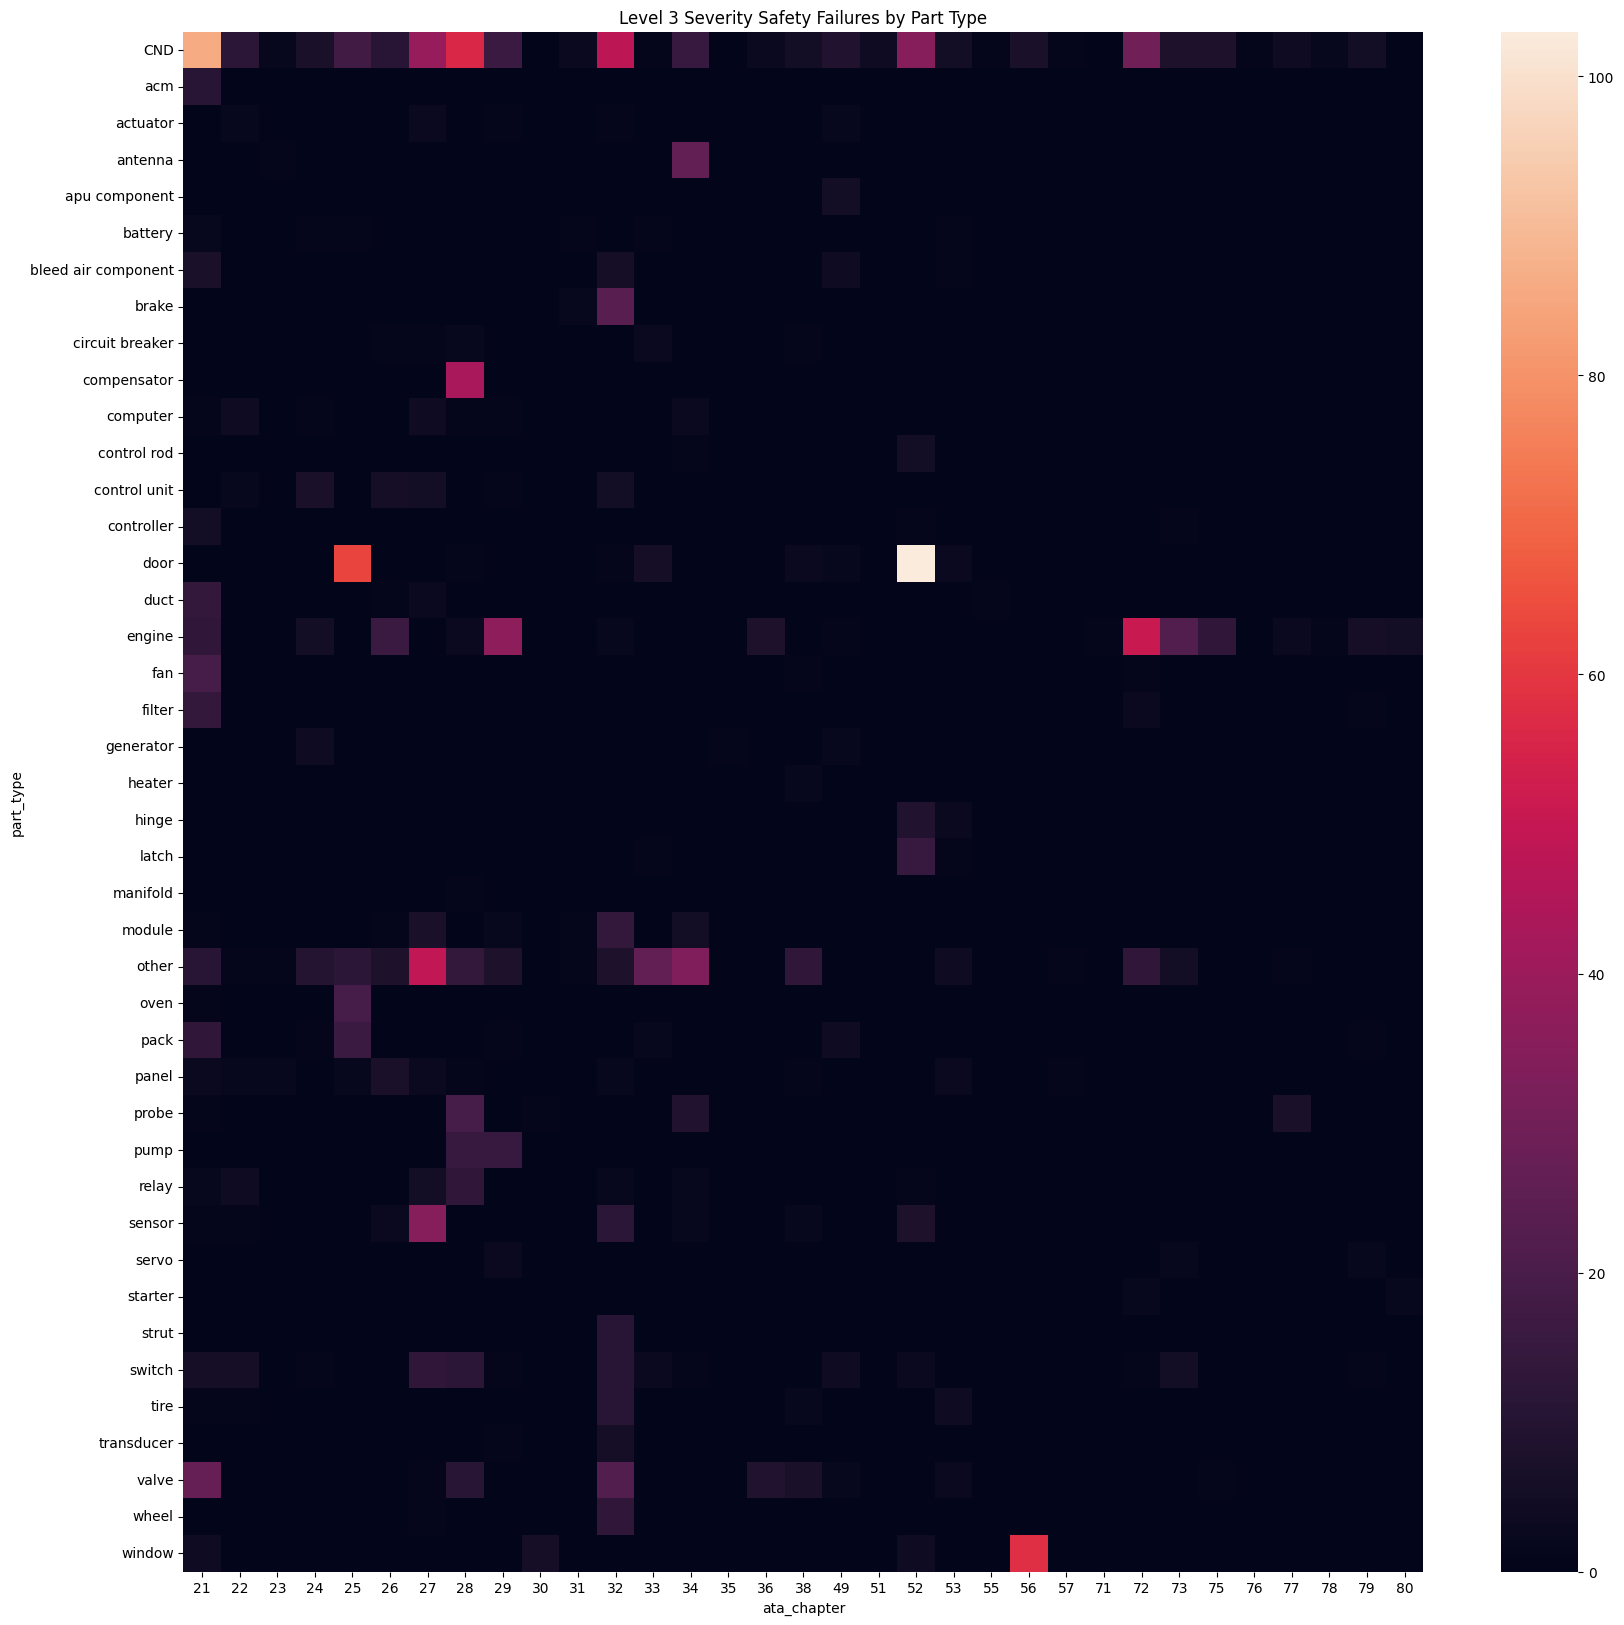

In [40]:
my_df = interface.q_to_df("""    
WITH sev3 AS (
        SELECT
            s.operator_control_number,
            s.severity,
            s.discrepancy,
            s.part_number,
            s.part_name,
            left(s.jasc_code, 2) AS ata_chapter
        FROM sdr_event_aa AS s
        WHERE s.severity = 3
    ),

    part_types AS (
        SELECT
            operator_control_number,
            severity,
            part_number,
            part_name,
            discrepancy,
            ata_chapter,

            CASE
                WHEN discrepancy ILIKE '%could not duplicate%'
                  OR discrepancy ILIKE '%unable to determine%'
                  OR discrepancy ILIKE '%no fault%'
                  OR discrepancy ILIKE '%no defects%'
                  OR discrepancy ILIKE '%no evidence%'
                  OR discrepancy ILIKE '%not determine%'
                  OR discrepancy LIKE '%(OPEN)%'
                  THEN 'CND'
                WHEN part_name ILIKE '%engine%' OR discrepancy ILIKE '%replaced%engine%' THEN 'engine'
                WHEN part_name ILIKE '%window%' OR discrepancy ILIKE '%window%' THEN 'window'
                WHEN part_name ILIKE '%oven%' OR discrepancy ILIKE '%oven%' THEN 'oven'
                WHEN part_name ILIKE '%windshield%' OR discrepancy ILIKE '%windshield%' THEN 'window'
                WHEN part_name ILIKE '%compensator%' OR discrepancy ILIKE '%compensator%' THEN 'compensator'
                WHEN part_name ILIKE '%control unit%' OR discrepancy ILIKE '%control unit%' THEN 'control unit'
                WHEN part_name ILIKE '%valve%' OR discrepancy ILIKE '%valve%' THEN 'valve'
                WHEN part_name ILIKE '%acm%' OR discrepancy ILIKE '%acm%' THEN 'acm'
                WHEN part_name ILIKE '%duct%' OR discrepancy ILIKE '%duct%' THEN 'duct'
                WHEN part_name ILIKE '%regulator%' OR discrepancy ILIKE '%regulator%' THEN 'regulator'
                WHEN part_name ILIKE '%manifold%' OR discrepancy ILIKE '%manifold%' THEN 'manifold'
                WHEN part_name ILIKE '%bleed%' OR discrepancy ILIKE '%bleed%' THEN 'bleed air component'
                WHEN part_name ILIKE '%pack%' OR discrepancy ILIKE '%pack%' THEN 'pack'
                WHEN part_name ILIKE '%relay%' OR discrepancy ILIKE '%relay%' THEN 'relay'
                WHEN part_name ILIKE '%switch%' OR discrepancy ILIKE '%switch%' THEN 'switch'
                WHEN part_name ILIKE '%breaker%' OR discrepancy ILIKE '%breaker%' THEN 'circuit breaker'
                WHEN part_name ILIKE '%generator%' OR discrepancy ILIKE '%generator%' THEN 'generator'
                WHEN part_name ILIKE '%battery%' OR discrepancy ILIKE '%battery%' THEN 'battery'
                WHEN part_name ILIKE '%sensor%' OR discrepancy ILIKE '%sensor%' THEN 'sensor'
                WHEN part_name ILIKE '%probe%' OR discrepancy ILIKE '%probe%' THEN 'probe'
                WHEN part_name ILIKE '%transducer%' OR discrepancy ILIKE '%transducer%' THEN 'transducer'
                WHEN part_name ILIKE '%antenna%' OR discrepancy ILIKE '%antenna%' THEN 'antenna'
                WHEN part_name ILIKE '%controller%' OR discrepancy ILIKE '%controller%' THEN 'controller'
                WHEN part_name ILIKE '%computer%' OR discrepancy ILIKE '%computer%' THEN 'computer'
                WHEN part_name ILIKE '%module%' OR discrepancy ILIKE '%module%' THEN 'module'
                WHEN part_name ILIKE '%actuator%' OR discrepancy ILIKE '%actuator%' THEN 'actuator'
                WHEN part_name ILIKE '%servo%' OR discrepancy ILIKE '%servo%' THEN 'servo'
                WHEN part_name ILIKE '%rod%' OR discrepancy ILIKE '%rod%' THEN 'control rod'
                WHEN part_name ILIKE '%hinge%' OR discrepancy ILIKE '%hinge%' THEN 'hinge'
                WHEN part_name ILIKE '%pump%' OR discrepancy ILIKE '%pump%' THEN 'pump'
                WHEN part_name ILIKE '%reservoir%' OR discrepancy ILIKE '%reservoir%' THEN 'reservoir'
                WHEN part_name ILIKE '%accumulator%' OR discrepancy ILIKE '%accumulator%' THEN 'accumulator'
                WHEN part_name ILIKE '%strut%' OR discrepancy ILIKE '%strut%' THEN 'strut'
                WHEN part_name ILIKE '%brake%' OR discrepancy ILIKE '%brake%' THEN 'brake'
                WHEN part_name ILIKE '%wheel%' OR discrepancy ILIKE '%wheel%' THEN 'wheel'
                WHEN part_name ILIKE '%tire%' OR discrepancy ILIKE '%tire%' THEN 'tire'
                WHEN part_name ILIKE '%panel%' OR discrepancy ILIKE '%panel%' THEN 'panel'
                WHEN part_name ILIKE '%latch%' OR discrepancy ILIKE '%latch%' THEN 'latch'
                WHEN part_name ILIKE '%door%' OR discrepancy ILIKE '%door%' THEN 'door'
                WHEN part_name ILIKE '%fan%' OR discrepancy ILIKE '%fan%' THEN 'fan'
                WHEN part_name ILIKE '%filter%' OR discrepancy ILIKE '%filter%' THEN 'filter'
                WHEN part_name ILIKE '%heater%' OR discrepancy ILIKE '%heater%' THEN 'heater'
                WHEN part_name ILIKE '%starter%' OR discrepancy ILIKE '%starter%' THEN 'starter'
                WHEN part_name ILIKE '%apu%' OR discrepancy ILIKE '%apu%' THEN 'apu component'
                -- WHEN part_name ILIKE '%light%' OR discrepancy ILIKE '%light%' THEN 'light' --(JUST INDICATION FOR GROUNDING WRITEUP!!!)
                ELSE 'other'
            END AS part_type

        FROM sev3
    ),

    my_table AS (
        SELECT
            part_type,
            ata_chapter,
            COUNT(*) AS event_count
        FROM part_types
        GROUP BY part_type, ata_chapter
    )

    SELECT *
    FROM my_table
    ORDER BY event_count DESC;
""")
df_part_ata = my_df.pivot(index = 'part_type', columns='ata_chapter', values='event_count').astype(float).fillna(0.0)

df_part_ata.to_csv('my_export.csv')

plt.figure(figsize=(20,20))
sns.heatmap(df_part_ata)
plt.title("Level 3 Severity Safety Failures by Part Type")
plt.show()

Create view for sdr events with failed component

In [ ]:
CREATE OR REPLACE VIEW sdr_event_aa_classified AS 
SELECT *, 
    CASE
        WHEN discrepancy ILIKE '%could not duplicate%'
            OR discrepancy ILIKE '%unable to determine%'
            OR discrepancy ILIKE '%no fault%'
            OR discrepancy ILIKE '%no defects%'
            OR discrepancy ILIKE '%no evidence%'
            OR discrepancy ILIKE '%not determine%'
            OR discrepancy LIKE '%(OPEN)%'
            THEN 'CND'
        WHEN part_name ILIKE '%engine%' OR discrepancy ILIKE '%replaced%engine%' THEN 'engine'
        WHEN part_name ILIKE '%window%' OR discrepancy ILIKE '%window%' THEN 'window'
        WHEN part_name ILIKE '%oven%' OR discrepancy ILIKE '%oven%' THEN 'oven'
        WHEN part_name ILIKE '%windshield%' OR discrepancy ILIKE '%windshield%' THEN 'window'
        WHEN part_name ILIKE '%compensator%' OR discrepancy ILIKE '%compensator%' THEN 'compensator'
        WHEN part_name ILIKE '%control unit%' OR discrepancy ILIKE '%control unit%' THEN 'control unit'
        WHEN part_name ILIKE '%valve%' OR discrepancy ILIKE '%valve%' THEN 'valve'
        WHEN part_name ILIKE '%acm%' OR discrepancy ILIKE '%acm%' THEN 'acm'
        WHEN part_name ILIKE '%duct%' OR discrepancy ILIKE '%duct%' THEN 'duct'
        WHEN part_name ILIKE '%regulator%' OR discrepancy ILIKE '%regulator%' THEN 'regulator'
        WHEN part_name ILIKE '%manifold%' OR discrepancy ILIKE '%manifold%' THEN 'manifold'
        WHEN part_name ILIKE '%bleed%' OR discrepancy ILIKE '%bleed%' THEN 'bleed air component'
        WHEN part_name ILIKE '%pack%' OR discrepancy ILIKE '%pack%' THEN 'pack'
        WHEN part_name ILIKE '%relay%' OR discrepancy ILIKE '%relay%' THEN 'relay'
        WHEN part_name ILIKE '%switch%' OR discrepancy ILIKE '%switch%' THEN 'switch'
        WHEN part_name ILIKE '%breaker%' OR discrepancy ILIKE '%breaker%' THEN 'circuit breaker'
        WHEN part_name ILIKE '%generator%' OR discrepancy ILIKE '%generator%' THEN 'generator'
        WHEN part_name ILIKE '%battery%' OR discrepancy ILIKE '%battery%' THEN 'battery'
        WHEN part_name ILIKE '%sensor%' OR discrepancy ILIKE '%sensor%' THEN 'sensor'
        WHEN part_name ILIKE '%probe%' OR discrepancy ILIKE '%probe%' THEN 'probe'
        WHEN part_name ILIKE '%transducer%' OR discrepancy ILIKE '%transducer%' THEN 'transducer'
        WHEN part_name ILIKE '%antenna%' OR discrepancy ILIKE '%antenna%' THEN 'antenna'
        WHEN part_name ILIKE '%controller%' OR discrepancy ILIKE '%controller%' THEN 'controller'
        WHEN part_name ILIKE '%computer%' OR discrepancy ILIKE '%computer%' THEN 'computer'
        WHEN part_name ILIKE '%module%' OR discrepancy ILIKE '%module%' THEN 'module'
        WHEN part_name ILIKE '%actuator%' OR discrepancy ILIKE '%actuator%' THEN 'actuator'
        WHEN part_name ILIKE '%servo%' OR discrepancy ILIKE '%servo%' THEN 'servo'
        WHEN part_name ILIKE '%rod%' OR discrepancy ILIKE '%rod%' THEN 'control rod'
        WHEN part_name ILIKE '%hinge%' OR discrepancy ILIKE '%hinge%' THEN 'hinge'
        WHEN part_name ILIKE '%pump%' OR discrepancy ILIKE '%pump%' THEN 'pump'
        WHEN part_name ILIKE '%reservoir%' OR discrepancy ILIKE '%reservoir%' THEN 'reservoir'
        WHEN part_name ILIKE '%accumulator%' OR discrepancy ILIKE '%accumulator%' THEN 'accumulator'
        WHEN part_name ILIKE '%strut%' OR discrepancy ILIKE '%strut%' THEN 'strut'
        WHEN part_name ILIKE '%brake%' OR discrepancy ILIKE '%brake%' THEN 'brake'
        WHEN part_name ILIKE '%wheel%' OR discrepancy ILIKE '%wheel%' THEN 'wheel'
        WHEN part_name ILIKE '%tire%' OR discrepancy ILIKE '%tire%' THEN 'tire'
        WHEN part_name ILIKE '%panel%' OR discrepancy ILIKE '%panel%' THEN 'panel'
        WHEN part_name ILIKE '%latch%' OR discrepancy ILIKE '%latch%' THEN 'latch'
        WHEN part_name ILIKE '%door%' OR discrepancy ILIKE '%door%' THEN 'door'
        WHEN part_name ILIKE '%fan%' OR discrepancy ILIKE '%fan%' THEN 'fan'
        WHEN part_name ILIKE '%filter%' OR discrepancy ILIKE '%filter%' THEN 'filter'
        WHEN part_name ILIKE '%heater%' OR discrepancy ILIKE '%heater%' THEN 'heater'
        WHEN part_name ILIKE '%starter%' OR discrepancy ILIKE '%starter%' THEN 'starter'
        WHEN part_name ILIKE '%apu%' OR discrepancy ILIKE '%apu%' THEN 'apu component'
        -- WHEN part_name ILIKE '%light%' OR discrepancy ILIKE '%light%' THEN 'light' --(JUST INDICATION FOR GROUNDING WRITEUP!!!)
        ELSE 'other'
    END AS failed_part
FROM sdr_event_aa;

SELECT *
from sdr_event_aa_classified
LIMIT 10;

## Doors
### Failure-Mode Clustering

In [ ]:
WITH temp AS (SELECT discrepancy,
    /* PART CLASSIFICATION */
    CASE
        WHEN discrepancy ILIKE '%(OPEN)%' THEN 'NOT '
        WHEN discrepancy ILIKE '%guide arm%' THEN 'guide arm'
        WHEN discrepancy ILIKE '%radius link%' THEN 'radius link'
        WHEN discrepancy ILIKE '%roller%' THEN 'roller'
        WHEN discrepancy ILIKE '%snubber%' THEN 'snubber'
        WHEN discrepancy ILIKE '%girt bar%' THEN 'girt bar'
        WHEN discrepancy ILIKE '%retainer clip%' THEN 'retainer clip'
        WHEN discrepancy ILIKE '%handle%' THEN 'handle'
        WHEN discrepancy ILIKE '%latch%' THEN 'latch'
        WHEN discrepancy ILIKE '%lock%' THEN 'lock'
        WHEN discrepancy ILIKE '%threshold%' THEN 'threshold'
        WHEN discrepancy ILIKE '%track%' THEN 'track'
        WHEN discrepancy ILIKE '%slide%' THEN 'slide assembly'
        WHEN discrepancy ILIKE '%exit sign%' THEN 'exit sign'
        WHEN discrepancy ILIKE '%corrosion%' THEN 'structure'
        ELSE 'other door component'
    END AS door_part,

    /* FAILURE MODE CLASSIFICATION */
    CASE
        WHEN discrepancy ILIKE '%difficult%' 
          OR discrepancy ILIKE '%hard to%' 
          OR discrepancy ILIKE '%stuck%' 
          OR discrepancy ILIKE '%sticks%' 
          THEN 'sticking / binding'

        WHEN discrepancy ILIKE '%loose%' THEN 'loose'
        WHEN discrepancy ILIKE '%broken%' THEN 'broken'
        WHEN discrepancy ILIKE '%misaligned%' 
          OR discrepancy ILIKE '%alignment%' THEN 'misaligned'
        WHEN discrepancy ILIKE '%corrosion%' THEN 'corroded'
        WHEN discrepancy ILIKE '%missing%' THEN 'missing'
        WHEN discrepancy ILIKE '%inoperative%' THEN 'inoperative'
        WHEN discrepancy ILIKE '%not seated%' 
          OR discrepancy ILIKE '%falling out%' THEN 'not seated'
        WHEN discrepancy ILIKE '%arm%' AND discrepancy ILIKE '%difficult%' THEN 'arm/disarm difficulty'
        ELSE 'other failure mode'
    END AS failure_mode

FROM sdr_event_aa_classified
WHERE discrepancy ILIKE '%door%' AND severity = 3)

SELECT discrepancy
FROM temp
WHERE door_part = 'other door component';

<Axes: xlabel='failure_mode', ylabel='door_part'>

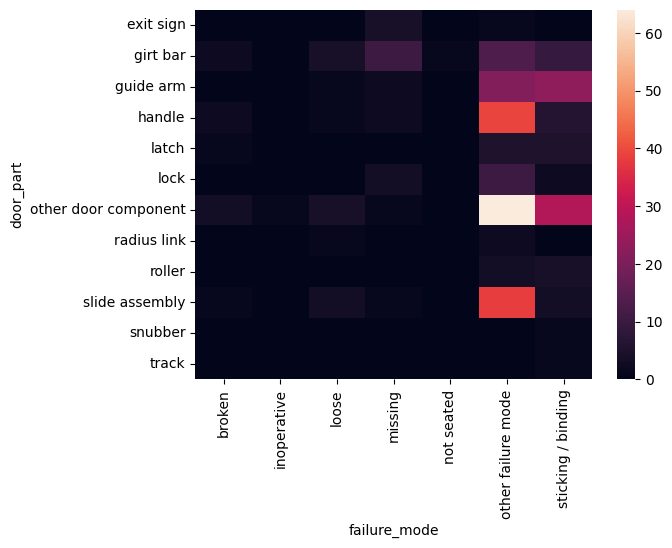

In [44]:
my_df = interface.q_to_df("""
SELECT 
    /* PART CLASSIFICATION */
    CASE
        WHEN discrepancy ILIKE '%guide arm%' THEN 'guide arm'
        WHEN discrepancy ILIKE '%radius link%' THEN 'radius link'
        WHEN discrepancy ILIKE '%roller%' THEN 'roller'
        WHEN discrepancy ILIKE '%snubber%' THEN 'snubber'
        WHEN discrepancy ILIKE '%girt bar%' THEN 'girt bar'
        WHEN discrepancy ILIKE '%retainer clip%' THEN 'retainer clip'
        WHEN discrepancy ILIKE '%handle%' THEN 'handle'
        WHEN discrepancy ILIKE '%latch%' THEN 'latch'
        WHEN discrepancy ILIKE '%lock%' THEN 'lock'
        WHEN discrepancy ILIKE '%threshold%' THEN 'threshold'
        WHEN discrepancy ILIKE '%track%' THEN 'track'
        WHEN discrepancy ILIKE '%slide%' THEN 'slide assembly'
        WHEN discrepancy ILIKE '%exit sign%' THEN 'exit sign'
        WHEN discrepancy ILIKE '%corrosion%' THEN 'structure'
        ELSE 'other door component'
    END AS door_part,

    /* FAILURE MODE CLASSIFICATION */
    CASE
        WHEN discrepancy ILIKE '%difficult%' 
          OR discrepancy ILIKE '%hard to%' 
          OR discrepancy ILIKE '%stuck%' 
          OR discrepancy ILIKE '%sticks%' 
          THEN 'sticking / binding'

        WHEN discrepancy ILIKE '%loose%' THEN 'loose'
        WHEN discrepancy ILIKE '%broken%' THEN 'broken'
        WHEN discrepancy ILIKE '%misaligned%' 
          OR discrepancy ILIKE '%alignment%' THEN 'misaligned'
        WHEN discrepancy ILIKE '%corrosion%' THEN 'corroded'
        WHEN discrepancy ILIKE '%missing%' THEN 'missing'
        WHEN discrepancy ILIKE '%inoperative%' THEN 'inoperative'
        WHEN discrepancy ILIKE '%not seated%' 
          OR discrepancy ILIKE '%falling out%' THEN 'not seated'
        WHEN discrepancy ILIKE '%arm%' AND discrepancy ILIKE '%difficult%' THEN 'arm/disarm difficulty'
        ELSE 'other failure mode'
    END AS failure_mode,

    COUNT(*) AS event_count

FROM sdr_event_aa_classified
WHERE discrepancy ILIKE '%door%' AND
    severity = 3
GROUP BY door_part, failure_mode
ORDER BY event_count DESC;
""")



my_df = my_df.pivot(index='door_part', columns='failure_mode', values='event_count').astype(float).fillna(0.0)
sns.heatmap(my_df)

1. Failure‑mode clustering within doors

You can classify door failures into categories:

    Rigging issues (most common)

    Guide arm / radius link wear

    Roller failures

    Gust lock failures

    Door handle migration

    Seal leaks

    Slide deployment / partial deployment

    Indication system faults

    Latch/stop pin misadjustment

Each cluster points to different root causes.
2. Flight‑phase patterns

Your logs explicitly mention:

    handle movement during climb

    door lights during takeoff roll

    seal leaks in cruise

    handle migration on landing

    vibration/noise after takeoff

This lets you map failures to pressurization load, thermal expansion, or vibration loads.
3. Repeat write‑ups

You have multiple “repeat gripe” and “third time today” entries.
This is a reliability red flag indicating:

    troubleshooting gaps

    incorrect rigging

    missing SB compliance

    worn components not replaced fully

Repeat events are gold for reliability analysis.
4. Maintenance action patterns

You can extract:

    which parts are replaced most often

    which repairs are temporary vs. permanent

    which AMM tasks appear repeatedly

    which components are “frequent flyers”

This helps identify weak points in the maintenance program.
5. Human‑factor contributors

Several logs mention:

    catering damaging doors

    slide armed when opened

    slide partially deployed due to handling

    girt bar issues

    door not stowed properly

This suggests training or procedural issues.
6. Environmental contributors

Some logs mention:

    vibration

    noise

    pressure leaks

    handle movement at altitude

These correlate with:

    pressurization cycles

    thermal expansion

    aerodynamic loads

You can map these to ATA 21/36 interactions.


1. Which door components fail most often

You can extract counts for:

    guide arms

    rollers

    radius links

    snubbers

    gust locks

    seals

    girt bars

    slide assemblies

This gives you a part‑level reliability ranking.
2. Which ATA chapters interact with door failures

Your logs show cross‑ATA interactions:

    ATA 21 (pressurization)

    ATA 52 (doors)

    ATA 25 (slides)

    ATA 38 (lavatory leaks affecting door area)

    ATA 49 (APU fumes affecting door area)

This helps identify systemic issues.
3. Which doors (L1, L2, R1, R2, etc.) fail most often

You can map failures by door position:

    L1 is the highest‑cycle door → highest failure rate

    L2/R2 often fail due to catering

    R1 often fails due to service door usage

This is actionable for maintenance planning.
4. Which failures cause emergency declarations

Your logs include:

    seal leaks

    loud noises

    door handle movement

    door lights in flight

    vibration/buffeting

You can isolate the subset of door failures that escalate to emergencies.
5. Which failures are CND (could not duplicate)

Door indication issues often produce CNDs because:

    rigging is intermittent

    sensors are sensitive

    handle movement is subtle

High CND rates indicate troubleshooting gaps.


## Air Conditioning (-21) Analysis
### Failure Modes

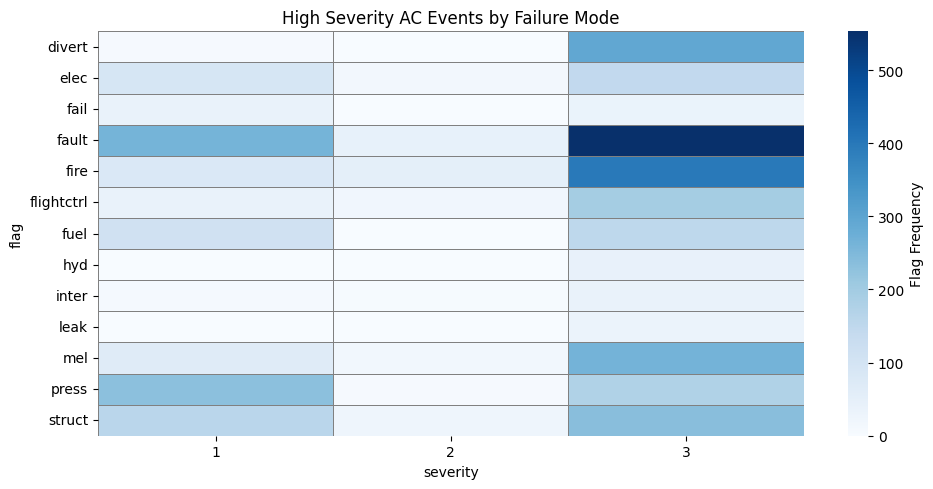

In [170]:
import os
import sys
sys.path.append(os.path.abspath(".."))
from util import sql_python_interface as interface
my_df = interface.q_to_df("""
                        SELECT  s.severity,
                                -- SUM(s.emer_flag::int) AS emer, (REDUNDANT, ALL CLASSIFIED AS SEV 3)
                                SUM(s.divert_flag::int) AS divert,
                                SUM(s.fail_flag::int) AS fail,
                                SUM(s.fault_flag::int) AS fault,
                                SUM(s.inter_flag::int) AS inter,
                                SUM(s.fire_flag::int) AS fire,
                                SUM(s.leak_flag::int) AS leak,
                                SUM(s.press_flag::int) AS press,
                                SUM(s.elec_flag::int) AS elec,
                                SUM(s.fuel_flag::int) AS fuel,
                                SUM(s.hyd_flag::int) AS hyd,
                                SUM(s.flightctrl_flag::int) AS flightctrl,
                                SUM(s.struct_flag::int) AS struct,
                                SUM(s.mel_flag::int) AS mel
                        FROM sdr_event_aa AS s
                        INNER JOIN jasc_code AS j
                                ON j.jasc_code = s.jasc_code
                        INNER JOIN ata_chapter AS a
                                ON j.ata_chapter = a.ata_chapter
                        GROUP BY s.severity
                        ORDER BY s.severity;
                          """)

# Melt so flags become rows
melted = my_df.melt(id_vars='severity', var_name='flag', value_name='frequency' )

# Pivot so flags = rows, severity = columns
df_keyword_heatmap = melted.pivot( index='flag', columns='severity', values='frequency').drop(columns=[0]).fillna(0)

plt.figure(figsize=(10, 5))  # ← make the plot MUCH bigger BEFORE drawing

ax = sns.heatmap(
    df_keyword_heatmap,
    cmap="Blues",
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={"label": "Flag Frequency"}
)

# Ensure y-labels are fully visible
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

# Expand margins so labels never get cut off
plt.subplots_adjust(
    left=0.35,   # more room for long ATA descriptions
    bottom=0.25, # more room for rotated x-labels
    right=0.95,
    top=0.95
)

plt.title('High Severity AC Events by Failure Mode')
plt.tight_layout()
plt.show()

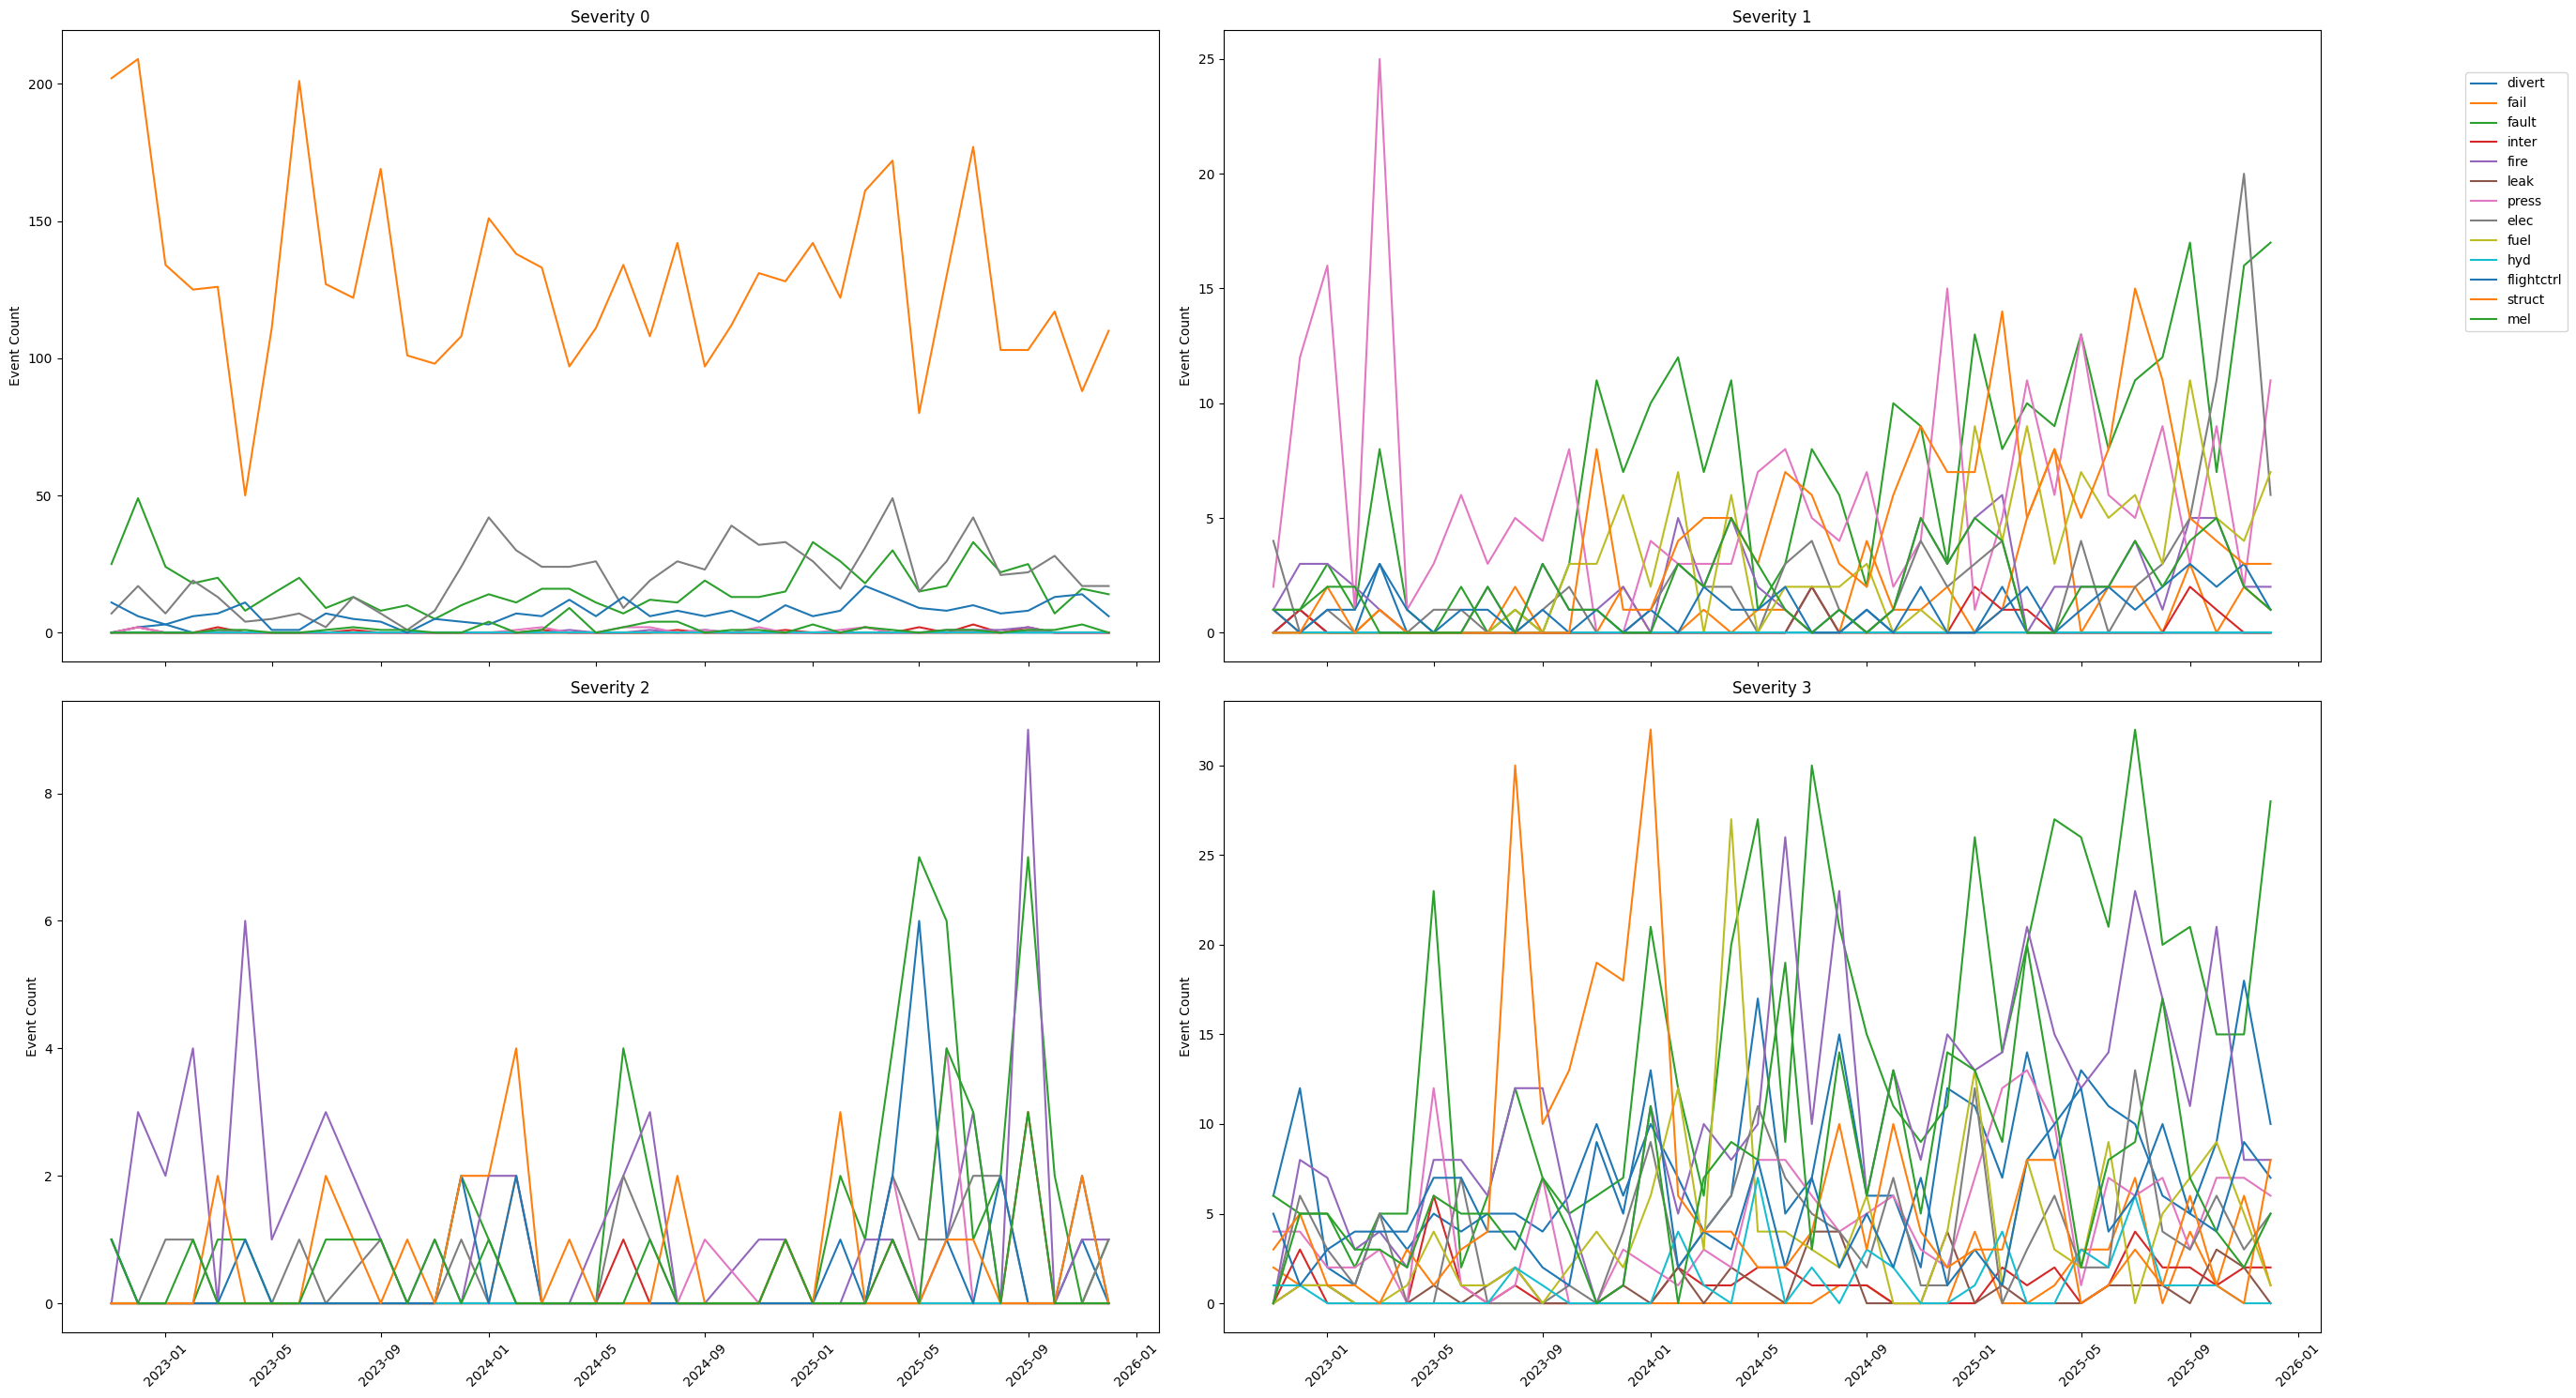

     month_num failure_type  count
0           11       divert      6
1           12       divert     12
2            1       divert      2
3            2       divert      1
4            3       divert      5
..         ...          ...    ...
489          8          mel     17
490          9          mel      7
491         10          mel      4
492         11          mel      2
493         12          mel      5

[494 rows x 3 columns]


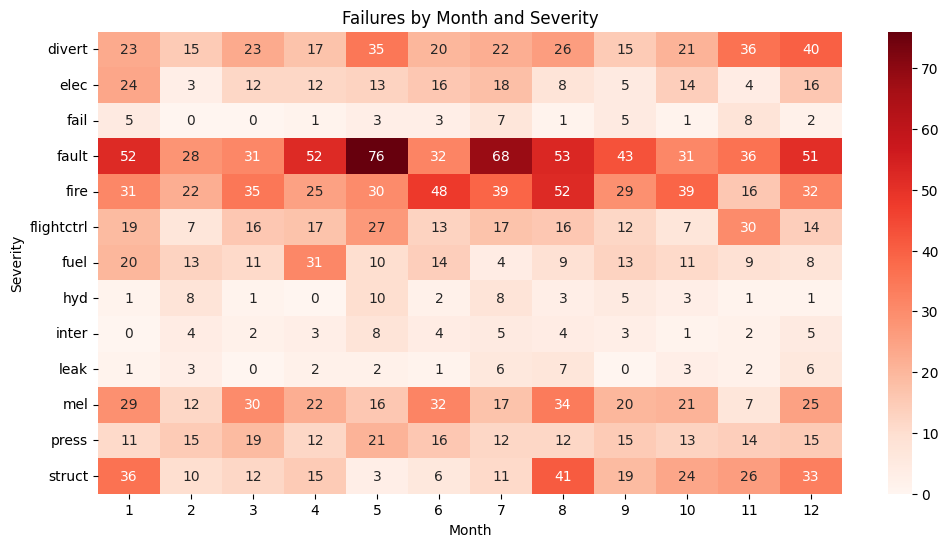

In [181]:
import os
import sys
sys.path.append(os.path.abspath(".."))
from util import sql_python_interface as interface
import matplotlib.pyplot as plt
import pandas as pd

# Pull monthly + severity + flags
my_df = interface.q_to_df("""
    SELECT 
        TO_DATE(s.difficulty_date::varchar, 'YYYY-MM') AS month,
        s.severity,
        SUM(s.divert_flag::int) AS divert,
        SUM(s.fail_flag::int) AS fail,
        SUM(s.fault_flag::int) AS fault,
        SUM(s.inter_flag::int) AS inter,
        SUM(s.fire_flag::int) AS fire,
        SUM(s.leak_flag::int) AS leak,
        SUM(s.press_flag::int) AS press,
        SUM(s.elec_flag::int) AS elec,
        SUM(s.fuel_flag::int) AS fuel,
        SUM(s.hyd_flag::int) AS hyd,
        SUM(s.flightctrl_flag::int) AS flightctrl,
        SUM(s.struct_flag::int) AS struct,
        SUM(s.mel_flag::int) AS mel
    FROM sdr_event_aa AS s
    GROUP BY month, s.severity
    ORDER BY month, s.severity;
""")

# Ensure month is sorted
my_df = my_df.sort_values("month")

# Flags to plot
flag_cols = [
    'divert', 'fail', 'fault', 'inter', 'fire', 'leak', 'press',
    'elec', 'fuel', 'hyd', 'flightctrl', 'struct', 'mel'
]

# Create 4 subplots (one per severity)
fig, axes = plt.subplots(2, 2, figsize=(25, 15), sharex=True)
severity_levels = [0, 1, 2, 3]

for ax, sev in zip(axes.flatten(), severity_levels):
    df_sev = my_df[my_df['severity'] == sev]

    for col in flag_cols:
        ax.plot(df_sev['month'], df_sev[col], label=col)

    ax.set_title(f"Severity {sev}")
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel("Event Count")

# Put legend outside the grid
fig.legend(flag_cols, loc='upper left', bbox_to_anchor=(1.05, 0.95))

plt.tight_layout()
plt.show()

my_df = (my_df[my_df['severity'] == 3]).drop(columns='severity')
my_df['month_num'] = pd.to_datetime(my_df['month']).dt.month

df_long = my_df.melt(
    id_vars=['month_num'],
    value_vars=flag_cols,
    var_name='failure_type',
    value_name='count'
)

heat = df_long.pivot_table(
    index='failure_type',
    columns='month_num',
    values='count',
    aggfunc='sum'
)

print(df_long)

plt.figure(figsize=(12,6))
sns.heatmap(heat, cmap='Reds', annot=True, fmt='g')
plt.title("Failures by Month and Severity")
plt.xlabel("Month")
plt.ylabel("Severity")
plt.show()


### JASC Concentration

   jasc  sev_3_freq  sev_2_freq  sev_1_freq  sev_0_freq jasc_code  \
0  2100           6           1           0           0      2100   
1  2120         139          15           0           0      2120   
2  2130          40           0           0           0      2130   
3  2140           1           0           0           0      2140   
4  2150          40           3           0           0      2150   
5  2160          14           0           0           0      2160   
6  2170           1           0           0           0      2170   

   ata_chapter                       description  
0           21           AIR CONDITIONING SYSTEM  
1           21           AIR DISTRIBUTION SYSTEM  
2           21     CABIN PRESSURE CONTROL SYSTEM  
3           21                    HEATING SYSTEM  
4           21              CABIN COOLING SYSTEM  
5           21  CABIN TEMPERATURE CONTROL SYSTEM  
6           21           HUMIDITY CONTROL SYSTEM  
                                  sev_3

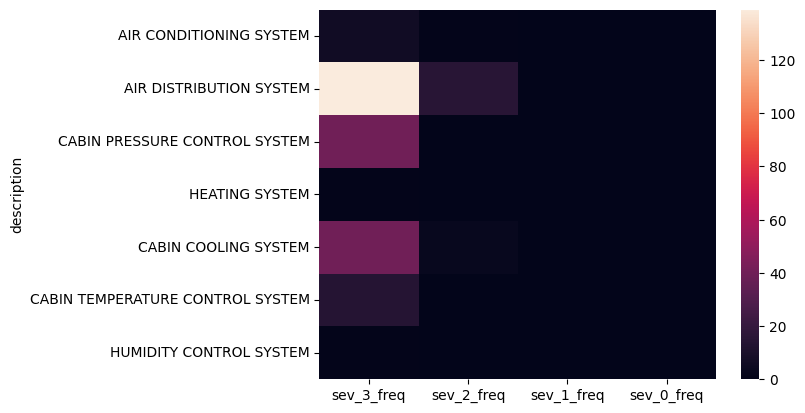

In [169]:
my_df = interface.q_to_df("""
                        WITH subsystem_table AS (
                          SELECT CONCAT(LEFT(s.jasc_code::varchar, 3), '0') AS jasc,
                                SUM(CASE WHEN s.severity = 3 THEN 1 ELSE 0 END) AS sev_3_freq,
                                SUM(CASE WHEN s.severity = 2 THEN 1 ELSE 0 END) AS sev_2_freq,
                                SUM(CASE WHEN s.severity = 1 THEN 1 ELSE 0 END) AS sev_1_freq,
                                SUM(CASE WHEN s.severity = 0 THEN 1 ELSE 0 END) AS sev_0_freq
                          FROM sdr_event_aa AS s
                          INNER JOIN jasc_code AS j
                                ON j.jasc_code = s.jasc_code
                          WHERE j.ata_chapter = 21
                          GROUP BY jasc
                          ORDER BY sev_3_freq DESC
                          )

                        SELECT *
                        FROM subsystem_table AS t
                        INNER JOIN jasc_code AS j
                              ON j.jasc_code = t.jasc; 
                          """)
print(my_df)
my_df = my_df.drop(columns=['jasc_code', 'jasc', 'ata_chapter']).set_index('description').astype(float)
print(my_df)


sns.heatmap(my_df)
plt.show()

### Components

In [ ]:
-- Distribution of ac pack failures with parts
SELECT
    COUNT(*) AS total_events,
    COUNT(part_number) AS events_with_part_number,
    COUNT(*) - COUNT(part_number) AS events_missing_part_number
FROM sdr_event_aa
WHERE LEFT(jasc_code, 2) = '21';

SyntaxError: invalid syntax (1473513277.py, line 1)

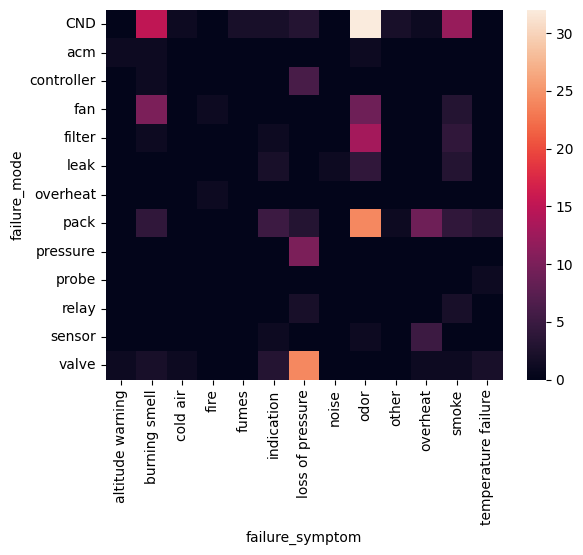

In [ ]:
my_df = interface.q_to_df("""
    WITH ata21_sev3 AS (
        SELECT
            s.operator_control_number,
            s.severity,
            s.discrepancy,
            s.part_number,
            s.part_name
        FROM sdr_event_aa AS s
        INNER JOIN jasc_code AS j
            ON j.jasc_code = s.jasc_code
        WHERE j.ata_chapter = 21
        AND s.severity = 3
    ),

    failure_modes AS (
        SELECT
            operator_control_number,
            severity,
            part_number,
            part_name,
            discrepancy,

            /* WHAT failed (component-level failure mode) */
            CASE
                WHEN discrepancy ILIKE '%valve%' THEN 'valve'
                WHEN discrepancy ILIKE '%pack%' THEN 'pack'
                WHEN discrepancy ILIKE '%acm%' THEN 'acm'
                WHEN discrepancy ILIKE '%controller%' THEN 'controller'
                WHEN discrepancy ILIKE '%sensor%' THEN 'sensor'
                WHEN discrepancy ILIKE '%pressure%' THEN 'pressure'
                WHEN discrepancy ILIKE '%leak%' THEN 'leak'
                WHEN discrepancy ILIKE '%fan%' THEN 'fan'
                WHEN discrepancy ILIKE '%filter%' THEN 'filter'
                WHEN discrepancy ILIKE '%probe%' THEN 'probe'
                WHEN discrepancy ILIKE '%overheat%' THEN 'overheat'
                WHEN discrepancy ILIKE '%relay%' THEN 'relay'
                WHEN discrepancy ILIKE '%did not identify%'
                OR discrepancy ILIKE '%(OPEN)%'
                OR discrepancy ILIKE '%unable to determine%' 
                OR discrepancy ILIKE '%could not duplicate%' 
                OR discrepancy ILIKE '%not determine%'
                OR discrepancy ILIKE '%no%defects%' 
                OR discrepancy ILIKE '%no evidence%' 
                OR discrepancy ILIKE '%no finding%' 
                OR discrepancy ILIKE '%no fault%' 
                THEN 'CND'
                ELSE 'CND'
            END AS failure_mode,

            /* HOW it failed (symptom-level failure mode) */
            CASE
                WHEN discrepancy ILIKE '%smoke%' THEN 'smoke'
                WHEN discrepancy ILIKE '%fire%' THEN 'fire'
                WHEN discrepancy ILIKE '%burn%' THEN 'burning smell'
                WHEN discrepancy ILIKE '%odor%' OR discrepancy ILIKE '%odour%' THEN 'odor'
                WHEN discrepancy ILIKE '%smell%' THEN 'odor'
                WHEN discrepancy ILIKE '%fume%' THEN 'fumes'
                WHEN discrepancy ILIKE '%pressure%' OR discrepancy ILIKE '%pressur%' THEN 'loss of pressure'
                WHEN discrepancy ILIKE '%hot%' OR discrepancy ILIKE '%overheat%' THEN 'overheat'
                WHEN discrepancy ILIKE '%cold%' THEN 'cold air'
                WHEN discrepancy ILIKE '%noise%' OR discrepancy ILIKE '%loud%' THEN 'noise'
                WHEN discrepancy ILIKE '%vibration%' THEN 'vibration'
                WHEN discrepancy ILIKE '%altitude warning%' THEN 'altitude warning'
                WHEN discrepancy ILIKE '%temperature%' THEN 'temperature failure'
                WHEN discrepancy ILIKE '%light%' OR
                    discrepancy ILIKE '%illuminated%' THEN 'indication'
                ELSE 'other'
            END AS failure_symptom

        FROM ata21_sev3
    ),

    my_table AS (
        SELECT
            --discrepancy,
            failure_mode,
            failure_symptom,
            --COALESCE(part_number, 'UNKNOWN') AS part_number,
            --COALESCE(part_name, 'UNKNOWN') AS part_name,
            COUNT(*) AS event_count
        FROM failure_modes
        GROUP BY failure_mode, failure_symptom--, part_number, part_name--, discrepancy
    )

    -- SELECT discrepancy
    -- FROM my_table
    -- WHERE failure_symptom = 'other';

    SELECT *
    FROM my_table
    ORDER BY event_count DESC;
""")

my_df = my_df.pivot(index='failure_mode', columns='failure_symptom', values='event_count').astype(float).fillna(0.0)
my_df.to_csv(path_or_buf='myexport.csv')
sns.heatmap(my_df)
plt.show()

In [ ]:
    WITH ata21_sev3 AS (
        SELECT 
            s.operator_control_number,
            s.severity,
            s.discrepancy,
            s.part_number,
            s.part_name
        FROM sdr_event_aa AS s
        INNER JOIN jasc_code AS j
            ON j.jasc_code = s.jasc_code
        WHERE j.ata_chapter = 21
        AND s.severity = 3
    ),

    failure_modes AS (
        SELECT
            operator_control_number,
            severity,
            part_number,
            part_name,
            discrepancy,

            /* WHAT failed (component-level failure mode) */
            CASE
                WHEN discrepancy ILIKE '%valve%' THEN 'valve'
                WHEN discrepancy ILIKE '%pack%' THEN 'pack'
                WHEN discrepancy ILIKE '%acm%' THEN 'acm'
                WHEN discrepancy ILIKE '%controller%' THEN 'controller'
                WHEN discrepancy ILIKE '%sensor%' THEN 'sensor'
                WHEN discrepancy ILIKE '%pressure%' THEN 'pressure'
                WHEN discrepancy ILIKE '%leak%' THEN 'leak'
                WHEN discrepancy ILIKE '%fan%' THEN 'fan'
                WHEN discrepancy ILIKE '%filter%' THEN 'filter'
                WHEN discrepancy ILIKE '%probe%' THEN 'probe'
                WHEN discrepancy ILIKE '%overheat%' THEN 'overheat'
                WHEN discrepancy ILIKE '%relay%' THEN 'relay'
                WHEN discrepancy ILIKE '%did not identify%'
                OR discrepancy ILIKE '%(OPEN)%'
                OR discrepancy ILIKE '%unable to determine%' 
                OR discrepancy ILIKE '%could not duplicate%' 
                OR discrepancy ILIKE '%not determine%'
                OR discrepancy ILIKE '%no%defects%' 
                OR discrepancy ILIKE '%no evidence%' 
                OR discrepancy ILIKE '%no finding%' 
                OR discrepancy ILIKE '%no fault%' 
                THEN 'CND'
                ELSE 'CND'
            END AS failure_mode,

            /* HOW it failed (symptom-level failure mode) */
            CASE
                WHEN discrepancy ILIKE '%smoke%' THEN 'smoke'
                WHEN discrepancy ILIKE '%fire%' THEN 'fire'
                WHEN discrepancy ILIKE '%burn%' THEN 'burning smell'
                WHEN discrepancy ILIKE '%odor%' OR discrepancy ILIKE '%odour%' THEN 'odor'
                WHEN discrepancy ILIKE '%smell%' THEN 'odor'
                WHEN discrepancy ILIKE '%fume%' THEN 'fumes'
                WHEN discrepancy ILIKE '%pressure%' OR discrepancy ILIKE '%pressur%' THEN 'loss of pressure'
                WHEN discrepancy ILIKE '%hot%' OR discrepancy ILIKE '%overheat%' THEN 'overheat'
                WHEN discrepancy ILIKE '%cold%' THEN 'cold air'
                WHEN discrepancy ILIKE '%noise%' OR discrepancy ILIKE '%loud%' THEN 'noise'
                WHEN discrepancy ILIKE '%vibration%' THEN 'vibration'
                WHEN discrepancy ILIKE '%altitude warning%' THEN 'altitude warning'
                WHEN discrepancy ILIKE '%temperature%' THEN 'temperature failure'
                WHEN discrepancy ILIKE '%light%' OR
                    discrepancy ILIKE '%illuminated%' THEN 'indication'
                ELSE 'other'
            END AS failure_symptom

        FROM ata21_sev3
    ),

    my_table AS (
        SELECT
            discrepancy,
            failure_mode,
            failure_symptom,
            --COALESCE(part_number, 'UNKNOWN') AS part_number,
            --COALESCE(part_name, 'UNKNOWN') AS part_name,
            COUNT(*) AS event_count
        FROM failure_modes
        GROUP BY failure_mode, failure_symptom, discrepancy
    )

    SELECT discrepancy
    FROM my_table
    WHERE failure_mode = 'pack' AND failure_symptom = 'odor';